Files in directory: ['000027665-AbsorptionImageExpFrag.h5', '000027666-AbsorptionImageExpFrag.h5']
Available HDF5 files: ['000027665-AbsorptionImageExpFrag.h5', '000027666-AbsorptionImageExpFrag.h5']
Using file: ../results/2026-07-22/11/000027665-AbsorptionImageExpFrag.h5
File 1: ../results/2026-07-22/11/000027665-AbsorptionImageExpFrag.h5
File 2: ../results/2026-07-22/11/000027666-AbsorptionImageExpFrag.h5
Keys in the datasets: ['Images.absorption.BG', 'Images.absorption.REF', 'Images.absorption.TOF', 'Images.absorption.expansion_time', 'Images.absorption.settings', 'Images.absorption.timestamp', 'ndscan.rid_27665.analysis_results', 'ndscan.rid_27665.annotations', 'ndscan.rid_27665.axes', 'ndscan.rid_27665.channels', 'ndscan.rid_27665.completed', 'ndscan.rid_27665.execution_mode', 'ndscan.rid_27665.fragment_fqn', 'ndscan.rid_27665.ndscan_schema_revision', 'ndscan.rid_27665.online_analyses', 'ndscan.rid_27665.points.axis_0', 'ndscan.rid_27665.points.channel_atom_number', 'ndscan.rid_27

/home/ae19663/artiq/repository/imaging/processor.py:640: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


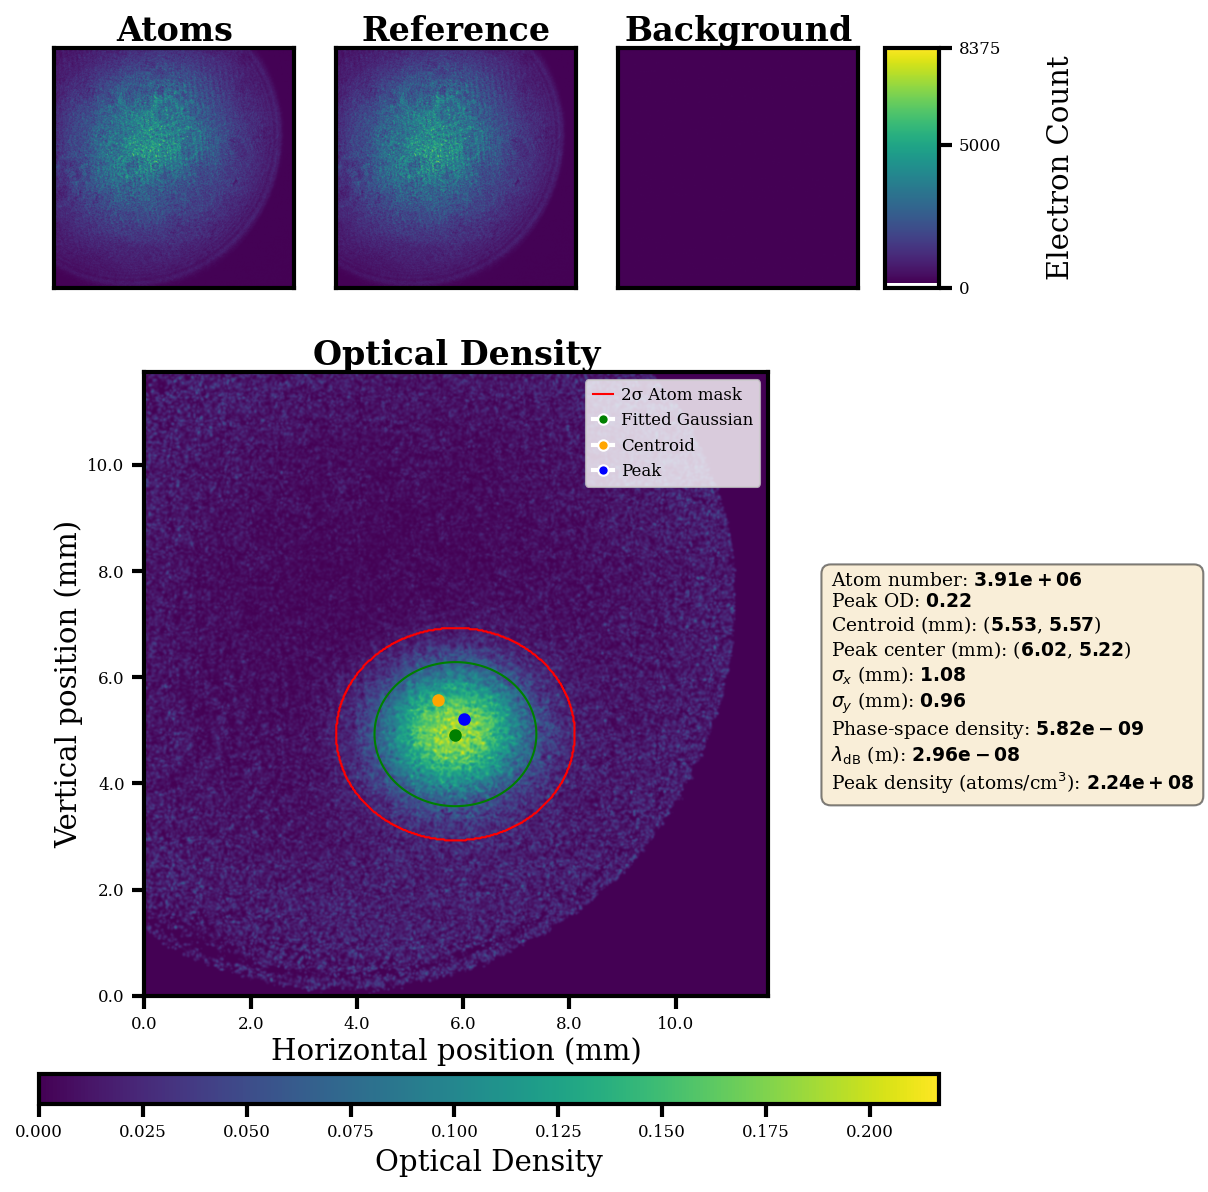

/home/ae19663/artiq/repository/imaging/processor.py:640: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


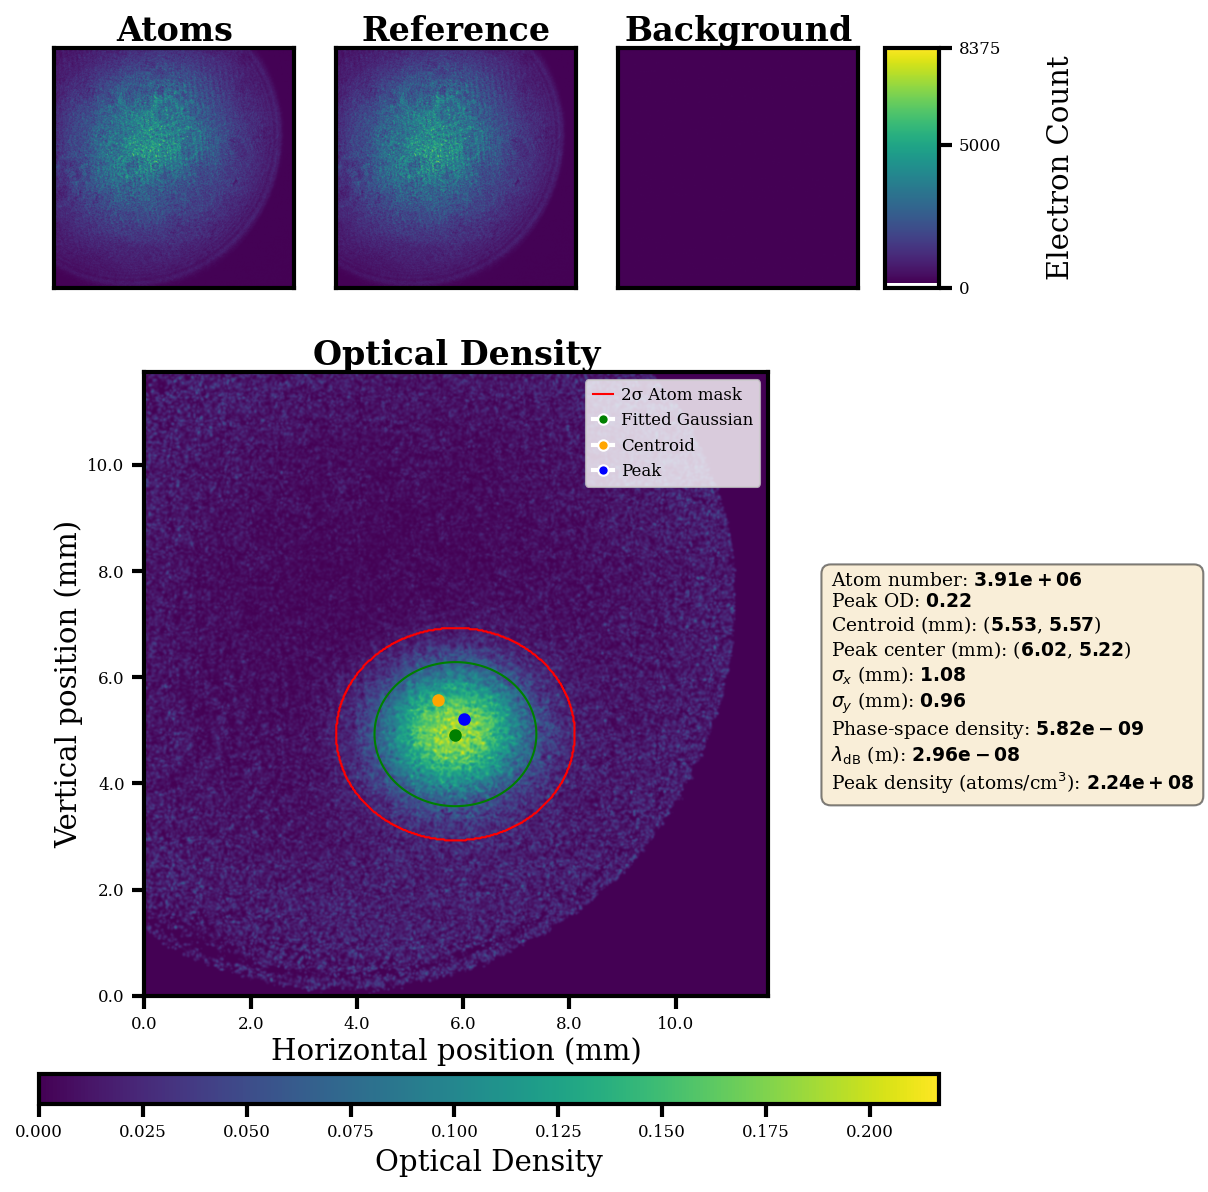

sigmax values: [1.0753643932513726, 1.0753643932513726]
sigmay values: [0.957236199095872, 0.957236199095872]


In [269]:
import h5py
from sipyco import pyon
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os as os
import sys
import scipy.constants as const

sys.path.append(
    "/home/ae19663/artiq"
)  # Adjust this path to the parent directory of 'repository'

# sys.path.append(
#    "/storage/Artiq_result_files"
# )  # Adjust this path to the parent directory of 'repository'
from repository.imaging.processor import AbsImage, AbsImageSettings  # noqa: E402


# it will take folder(scan path) path as input and return sorted list of h5 files DIRECTORY
# the files are sorted based on the numeric part of their names, which is before the first hyphen '-'.
# For example, if the files are named like "000001234-AbsorptionImageExpFrag.h5",
# the sorting will be based on the numeric part "000001234".

folder_directory = (
    "../results/2026-07-22/11/"  # Example directory path, adjust as needed
)


# folder_directory = (
#   "../Artiq_result_files/2025-09-10/12/"  # Example directory path, adjust as needed
# )
file_names = os.listdir(folder_directory)

# this will print the file names in the directory
print(f"Files in directory: {file_names}")


# Enter the name of the file you want to analyze.
# Pick an existing HDF5 file automatically from the selected folder.
available_files = sorted(
    f for f in os.listdir(folder_directory) if f.endswith(".h5")
)
print(f"Available HDF5 files: {available_files}")

preferred_file = None
for suffix in ("AbsorptionImageExpFrag.h5", "AnalysisResultExpFrag.h5"):
    preferred_file = next((f for f in available_files if f.endswith(suffix)), None)
    if preferred_file is not None:
        break

if preferred_file is None:
    raise FileNotFoundError(f"No HDF5 files found in {folder_directory}")

particular_directory = os.path.join(folder_directory, preferred_file)
print(f"Using file: {particular_directory}")


def sorted_files(directory):
    """
    Sort files in the given directory based on the numeric part of their names.
    """
    files = os.listdir(directory)
    file_num = []
    file_name = []

    for i in files:
        # Split the file name into two parts and sort by the numeric part
        file_num.append(i.split("-")[0])
        file_name.append(i.split("-")[1])

    # Sort the files based on the numeric part
    file_num, file_name = zip(*sorted(zip(file_num, file_name)))

    # Recombine the file number and file name into a single list
    sorted_files_list = [f"{num}-{name}" for num, name in zip(file_num, file_name)]

    # Directory list for the files using the sorted file names
    files_directory = [
        os.path.join(directory, f) for f in sorted_files_list if f.endswith(".h5")
    ]

    # Example usage:
    # directory = "../results/2025-07-08/21/"
    # files_directory = sorted_files(directory)

    return files_directory


def get_override_args(file_directory, hide_defaults=True):
    vals = {}

    f1 = h5py.File(file_directory, "r")
    args = pyon.decode(f1["expid"][()])["arguments"]
    for k, v in args.items():
        if k == "ndscan_params":
            params = pyon.decode(args["ndscan_params"])
            # print(params)
            overrides = params["overrides"]
            for k, v in overrides.items():
                spec = params["schemata"][k]["spec"]
                val = v[0]["value"]
                default = type(val)(params["schemata"][k]["default"])
                if hide_defaults and val == default:
                    continue
                # vals[k] = [val / spec.get("scale", 1), spec.get("unit", "")]
        else:
            vals[k] = [v, ""]
    return vals


vals = get_override_args(particular_directory, hide_defaults=False)
# print(vals)


def args_names_and_vals(vals):
    # Print arguments names and their values
    args_names = []
    args_vals = []
    for k, (v, unit) in vals.items():
        # print(f"{k} = {v} {unit}")
        args_names.append(k)
        args_vals.append(v)
    return args_names, args_vals


files_directory = sorted_files(folder_directory)
# print(files_directory)

matching_args = []
for i in range(len(files_directory)):
    print(f"File {i + 1}: {files_directory[i]}")
    vals1 = get_override_args(files_directory[i])
    args_name1, args_val1 = args_names_and_vals(vals)
    for j in range(len(files_directory)):
        vals2 = get_override_args(files_directory[j])
        args_name2, args_val2 = args_names_and_vals(vals2)
        if args_name1 == args_name2:
            # print(f"Matching arguments found for {files_directory[i]} and {files_directory[j]}")
            matching_args.append((files_directory[i], files_directory[j]))
        else:
            # print(f"No matching arguments for {files_directory[i]} and {files_directory[j]}")
            pass


images_list = []
# plot the absorption image of the particular run in the scan, it is still a work in progress not working properly
def plot_absorption_image(file_directory, run_number):
    f1 = h5py.File(file_directory, "r")
    image_0 = "Images.absorption.TOF"
    image_1 = "Images.absorption.REF"
    image_2 = "Images.absorption.BG"

    absimg = AbsImage(
        data=f1["datasets"][image_0][()],
        ref=f1["datasets"][image_1][()],
        bg=f1["datasets"][image_2][()],
        settings=AbsImageSettings(magnification=0.33),  # Set default magnification
    )
    sigmax = absimg.sigmax
    sigmay = absimg.sigmay
    absimg.plot()
    plt.show()
    return sigmax, sigmay


scan_number = 11  # Example scan number, adjust as needed

#plot_absorption_image(particular_directory, scan_number)
# Extracting the values and the units from the files
f1 = h5py.File(files_directory[0], "r")
a = f1["datasets"]
print(f"Keys in the datasets: {list(a.keys())}")

# calculate how many files are there in the directory
num_files = len(files_directory)
print(f"Number of files in the directory: {num_files}")


# extract all files images for scan parameter ranging from 0 to num_files fro 0 to 21
scan_param = [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
]

# Extracting the values and the units from the files


f1 = h5py.File(files_directory[0], "r")
a = f1["datasets"]
print(f"Keys in the datasets: {list(a.keys())}")

runs = 2
# # np.extract the images for all the runs in the scan parameter
sigmax_values = []
sigmay_values = []
for j in range(runs):
  a=plot_absorption_image(particular_directory, j)
  sigmax_values.append(a[0])
  sigmay_values.append(a[1])
print("sigmax values:", sigmax_values)
print("sigmay values:", sigmay_values)

#give me ooptical density and return that image and append it to images list


In [270]:
# example of the data structure in the file
import re

from matplotlib.pylab import append
scaling_factor =22.36 * 1e-6  # Convert to meters, adjust scaling factor as needed

all = [
    "ndscan.rid_6597.analysis_results",
    "ndscan.rid_6597.annotations",
    "ndscan.rid_6597.axes",
    "ndscan.rid_6597.channels",
    "ndscan.rid_6597.completed",
    "ndscan.rid_6597.fragment_fqn",
    "ndscan.rid_6597.ndscan_schema_revision",
    "ndscan.rid_6597.online_analyses",
    "ndscan.rid_6597.points.axis_0",
    "ndscan.rid_6597.points.channel_atom_number",
    "ndscan.rid_6597.points.channel_info",
    "ndscan.rid_6597.seed",
    "ndscan.rid_6597.source_id",
]

axis1 = True  # Set to True if axis_1 exists, otherwise False

# enter the file number you want to analyze
file_number = 1  # Example file number, adjust as needed

if file_number < 0 or file_number >= len(files_directory):
    raise ValueError(
        f"File number {file_number} is out of range. Please choose a number between 0 and {len(files_directory) - 1}."
    )


# Extracting the values and the units from the files
f1 = h5py.File(files_directory[file_number], "r")
# extract file name and run number from the file path

file_name = os.path.basename(files_directory[file_number])
run_number = int(file_name.split("-")[0])
c = "ndscan.rid_" + str(run_number) + ".points.channel_info"
d = "ndscan.rid_" + str(run_number) + ".points.axis_0"

# try to find axis1 and assign it a variable like axis0, if not found ignore it
if axis1:
    try:
        e = "ndscan.rid_" + str(run_number) + ".points.axis_1"
        coil_current = f1["datasets"][e][()]
        print("axis1 found")
        print(coil_current)
    except KeyError:
        axis1 = False
        print("axis_1 not found, proceeding without it.")
        e = None


a = f1["datasets"][c][()]
print(a)

peakx = []
peaky = []
centroidx = []
centroidy = []
wavelength = []
atom_number = []
A = []
sx = []
sy = []
x0 = []
y0 = []
phase_space_density = []
peak_od = []
physical_scale = []
detuning = []
linewidth = []
magnification = []
pixel_size = []
tekscope_ch1=[]
images_list = []

records = [a] if isinstance(a, bytes) else a

for i in range(len(records)):
    # decode if bytes, otherwise use as is
    if isinstance(records[i], bytes):
        decoded = records[i].decode("utf-8")
        lines = decoded.split("\n")

    else:
        lines = records[i]

    for line in lines:
        b = line.strip(",").split(":")
        key = b[0].strip().strip('"')
        if key == "wavelength":
            wavelength.append(float(b[1]))
        elif key == "atom_number":
            atom_number.append(float(b[1]))
        elif key == "peak_pixel":  # Assuming this is a key for peak pixels
            # extract numbers from tuple string
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                peakx.append(float(nums[1]))
                peaky.append(float(nums[0]))
                # If you want the third value, use float(nums[2])
            # else skip or handle error
        elif key == "centroid_pixel":  # Assuming this is a key for centroid pixels
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                centroidx.append(float(nums[1]))
                centroidy.append(float(nums[0]))
                # If you want the third value, use float(nums[2])

        elif (
            key == "phase_space_density"
        ):  # Assuming this is a key for phase space density
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                phase_space_density.append(float(nums[0]))

        elif (
            key == "peak_optical_density"
        ):  # Assuming this is a key for peak optical density
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                peak_od.append(float(nums[0]))

        elif key == "best_values_pixel":  # Assuming this is a key for some values
            # Extract dictionary from line
            match = re.search(r"\{(.+?)\}", line)
            if match:
                dict_str = match.group(1)
                items = dict_str.split(",")
                for item in items:
                    item = item.strip()
                    if ":" in item:
                        key_part, value_part = item.split(":", 1)
                        key_item = key_part.strip().strip("'")
                        value_str = value_part.strip()
                        # Convert to float or int
                        if "." in value_str or "e" in value_str:
                            value = float(value_str)
                        else:
                            value = int(value_str)
                        # Append to the correct list
                        if key_item == "A":
                            A.append(value)
                        elif key_item == "x0":
                            x0.append(value)
                        elif key_item == "y0":
                            y0.append(value)
                        elif key_item == "sx":
                            sx.append(value)
                        elif key_item == "sy":
                            sy.append(value)
                        elif key_item == "theta":
                            if "theta" not in locals():
                                theta = []
                            theta.append(value)
                        elif key_item == "z0":
                            if "z0" not in locals():
                                z0 = []
                            z0.append(value)
        elif key == "physical_scale":  # Assuming this is a key for physical scale
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            physical_scale.append(float(nums[0]))
            print("Physical Scale:", physical_scale)
        elif key == "detuning":  # Assuming this is a key for scan parameters
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            detuning.append(float(nums[0]))
            print("Detuning:", detuning)
        elif key == "linewidth":  # Assuming this is a key for scan parameters
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            linewidth.append(float(nums[0]))
            print("Linewidth:", linewidth)
        elif key == "magnification":  # Assuming this is a key for scan parameters
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            magnification.append(float(nums[0]))
            print("Magnification:", magnification)
        elif key == "pixel_size":  # Assuming this is a key for scan parameters
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            pixel_size.append(float(nums[0]))
            print("Pixel Size:", pixel_size)
        elif key == "tekscope_ch1":  # Assuming this is a key for scan parameters
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            tekscope_ch1.append(float(nums[0]))
            print("Tekscope Channel 1:", tekscope_ch1)
        elif key=="all_images":  # Assuming this is a key for scan parameters
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            images_list.append(float(nums[0]))
            print("All Images:", images_list)


if phase_space_density != None:
    print("Phase Space Density:", phase_space_density)
if peak_od != None:
    print("Peak Optical Density:", peak_od)


# extract scan parameters from the file
# scan_params = f1["datasets"][d][()]
# add more decimal places to scan params

# print(scan_params)

# list contents in datasets
datasets = list(f1["datasets"].keys())
print("Datasets in the file:", datasets)


# print the extracted values
print("Wavelength:", wavelength)
print("Atom Number:", atom_number)
print("Peak X:", peakx)
print("Peak Y:", peaky)
print("Centroid X:", centroidx)
print("Centroid Y:", centroidy)
print("A:", A)
print("Sx:", sx)
print("Sy:", sy)
print("X0:", x0)
print("Y0:", y0)
print("Phase Space Density:", phase_space_density)
print("Physical Scale:", physical_scale)
print("Detuning:", detuning)
print("Linewidth:", linewidth)
print("Magnification:", magnification)
print("Pixel Size:", pixel_size)
# print("Peak Optical Density:", peak_od)

# remove the 7th data point from all the lists
# wavelength = np.delete(wavelength, 6)
# atom_number = np.delete(atom_number, 6)
# peakx = np.delete(peakx, 6)
# peaky = np.delete(peaky, 6)
# centroidx = np.delete(centroidx, 6)
# centroidy = np.delete(centroidy, 6)
# A = np.delete(A, 6)
# sx = np.delete(sx, 6)
# sy = np.delete(sy, 6)
# x0 = np.delete(x0, 6)
# y0 = np.delete(y0, 6)
# phase_space_density = np.delete(phase_space_density, 6)
# peak_od = np.delete(peak_od, 6)
# scan_params = np.delete(scan_params, 6)


# store everything in the csv file also scan parameters
data = {
    "wavelength": wavelength,
    "atom_number": atom_number,
    "peakx": peakx,
    "peaky": peaky,
    "centroidx": centroidx,
    "centroidy": centroidy,
    "A": A,
    "sx": sx,
    "sy": sy,
    "x0": x0,
    "y0": y0,
    # "scan_params": scan_params,
    "phase_space_density": phase_space_density,
    "peak_optical_density": peak_od,
}


# max and minimum index of data in sx and y
min_index_sx = np.argmin(sx)
max_index_sx = np.argmax(sx)
min_index_y = np.argmin(peaky)
max_index_y = np.argmax(peaky)
max_index_sy = np.argmax(sy)
min_index_sy = np.argmin(sy)

print("Min index of sx:", min_index_sx)
print("Max index of sx:", max_index_sx)
print("Min index of peaky:", min_index_y)
print("Max index of peaky:", max_index_y)
print("Max index of sy:", max_index_sy)
print("Min index of sy:", min_index_sy)

# print values at those indices
print("Min value of sx(micron):", sx[min_index_sx] * 1.36)
print("Max value of sx(micron):", sx[max_index_sx] * 1.36)
print("Min value of peaky:", peaky[min_index_y])
print("Max value of peaky:", peaky[max_index_y])
print("Min value of sy(micron):", sy[min_index_sy] * 1.36)
print("Max value of sy(micron):", sy[max_index_sy] * 1.36)
#print all images in the images_list
print("All images in the images_list:", images_list)

# save file in this directory with file name as the run number
# output_directory = "./"
# output_file = os.path.join(output_directory, f"extracted_data_run_{run_number}.csv")
# df = pd.DataFrame(data)
# df.to_csv(output_file, index=False)
# print(f"Data saved to {output_file}")


scaling_factor = 22.36 * 1e-6
m = 1.443e-25  # mass of Rb87 in kg
T = 20e-6  # temperature in K


def phase_space_density(
    self, atom_number, sigma_x, sigma_y, T, m, scaling_factor=1
):
    """
    Calculate phase-space density for a thermal atomic cloud.

    Parameters
    ----------
    N : float
        Total number of atoms in the cloud.
    sigma_x, sigma_y, sigma_z : floats
        Position-space 1/e standard deviations (meters) along x, y, z.
    T : float
        Temperature in Kelvin.
    m : float
        Mass of one atom in kilograms.

    Returns
    -------
    n : float
        Number density (atoms per cubic meter).
    lambda_db : float
        Thermal de Broglie wavelength (meters).
    PSD : float
        Phase-space density (dimensionless, N λ³ / V).
    """

    sigma_x = sigma_x * scaling_factor
    sigma_y = sigma_y * scaling_factor
    sigma_z = sigma_x * scaling_factor

    # Volume of the cloud assuming Gaussian distribution, 3D
    # V = (2π)^(3/2) σx σy σz
    V = (2 * np.pi) ** (3 / 2) * sigma_x * sigma_y * sigma_z

    # Number density
    n = atom_number / V

    # Thermal de Broglie wavelength
    # λ_dB = h / sqrt(2 π m k_B T)
    lambda_db = const.h / np.sqrt(2 * np.pi * m * const.k * T)

    # Phase-space density: n * λ_dB^3
    PSD = n * lambda_db**3

    return n, lambda_db, PSD


number_density_derived = []
phase_space_density_derived = []
lambda_db_derived = []
scaling_factor =1


for i in range(len(sx)):
    n, lambda_db, PSD = phase_space_density(
        None, atom_number[i], sx[i], sy[i], T, m, scaling_factor
    )
    number_density_derived.append(n)
    phase_space_density_derived.append(PSD)
    lambda_db_derived.append(lambda_db)


axis_1 not found, proceeding without it.
[b'\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.29,\n            "atom_number": 12679886.411709595,\n            "peak_pixel": (261, 298, 0.41423406767423593),\n            "centroid_pixel": (281, 284, 0.31497252096946066),\n            "best_values_pixel": {\'A\': 0.3634525491348517, \'x0\': 300.27280805755265, \'y0\': 254.7904542164309, \'sx\': 60.531610666024356, \'sy\': 54.106283986607785, \'theta\': 0, \'z0\': 0},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.2241379310344828e-05,\n            "physical_scale": 2.2241379310344828e-05,\n            "phase_space_density": (369103567279278.9, 2.961156035142131e-08, 9.583675950768949e-09),\n            "peak_optical_density": 0.41423406767423593,\n            "Peak density (atoms/cm^3)": 3.69e+08,\n            "sigmax": 60.531610666024356,\n         

[  40.04289051   73.25261288  106.46954456  139.68736886  172.90209287
  206.1167114   239.31160147  272.49073755  305.74404064  338.95509974
  372.15846933  405.41307921  438.64399705  471.85368043  505.05615791
  538.478125    571.69672149  604.90807286  638.11984046  671.33541944
  704.55114254  737.76737838  770.98071209  804.20308496  837.41488207
  870.62334699  903.82915346  937.03956239  970.23658701 1003.44406554
 1036.64804179 1069.84452961 1103.04135393 1136.25201519 1169.43550241
 1202.63225301 1235.8243513  1269.02265109 1302.20835971 1335.39908631
 1368.59749407 1401.80273874 1435.00239223 1468.20812742 1501.40076433
 1534.60465963 1567.82465504 1601.02519276 1634.27786362 1667.47329404
 1700.67875945 1733.88036111 1767.06017358 1800.25396495 1833.4551089
 1866.66523124 1899.86405333 1933.07192443 1966.28246711 1999.47222577
 2032.66860092 2065.86455878 2099.05568232 2132.24506721 2165.4460277
 2198.64293557 2231.84701821 2265.04419371 2298.2476388  2331.44103591
 2364.65

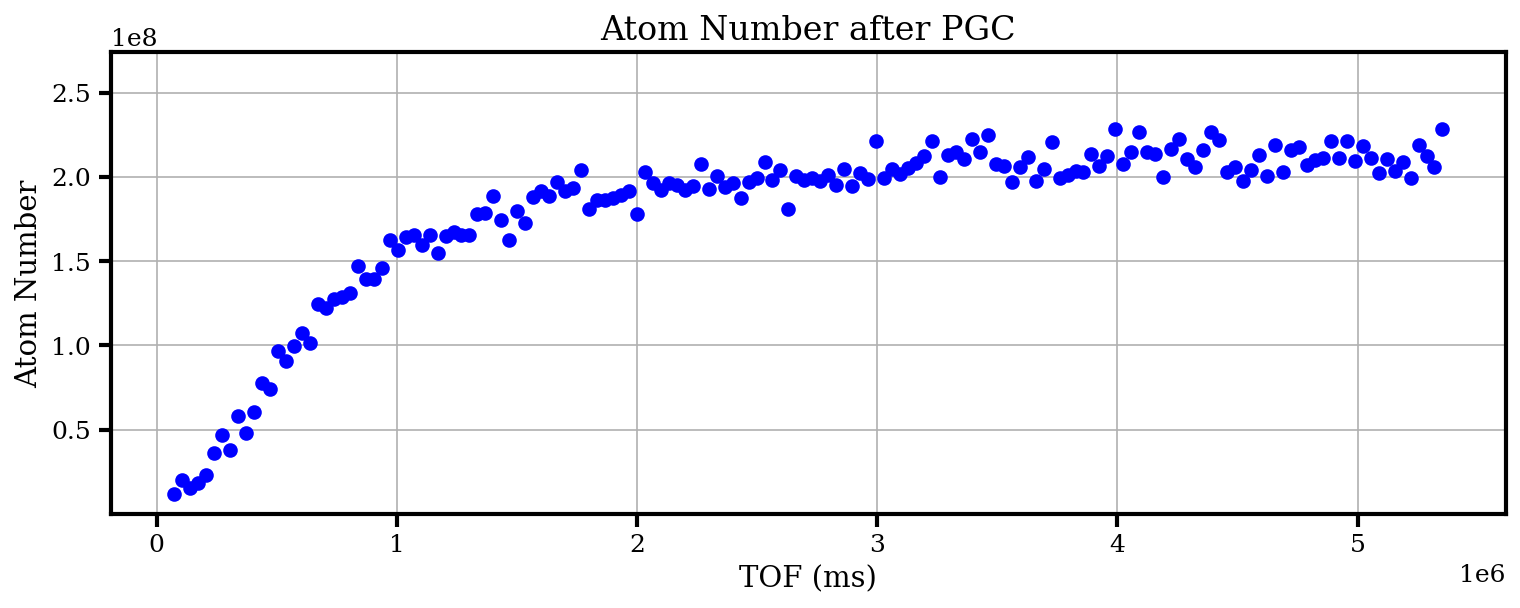

Number of bad data points in the atom number: 11


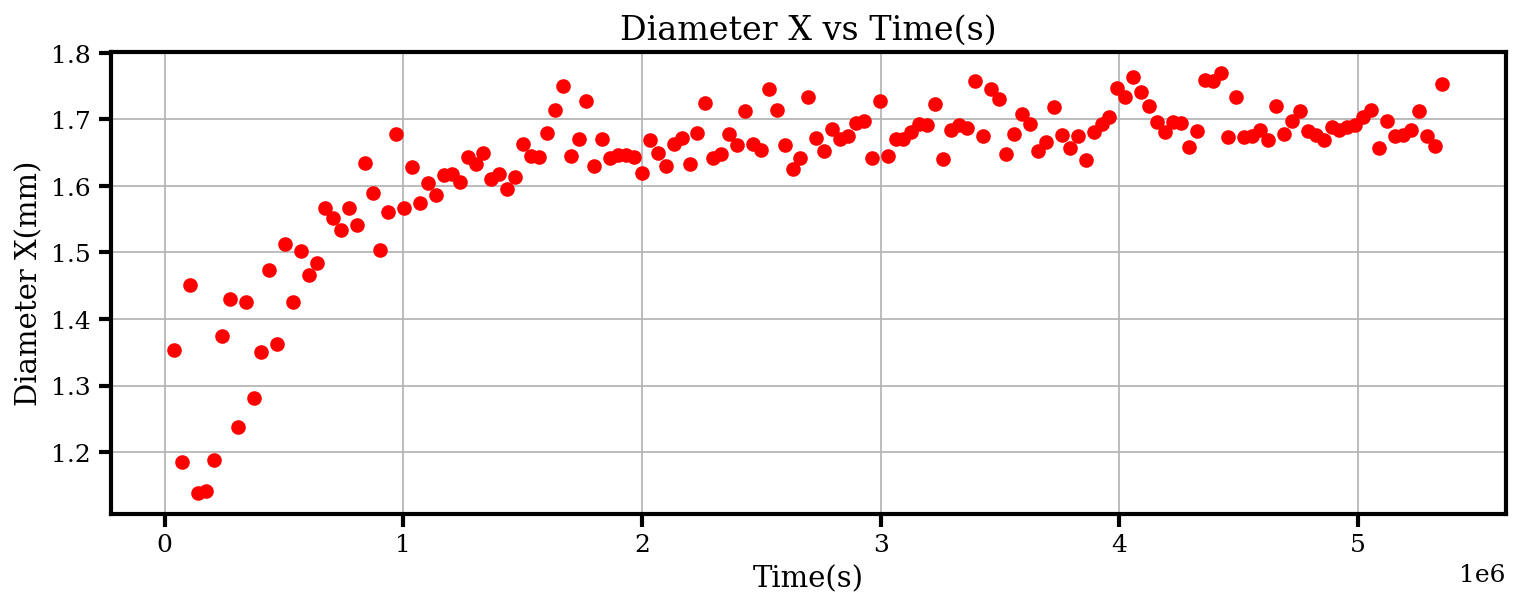

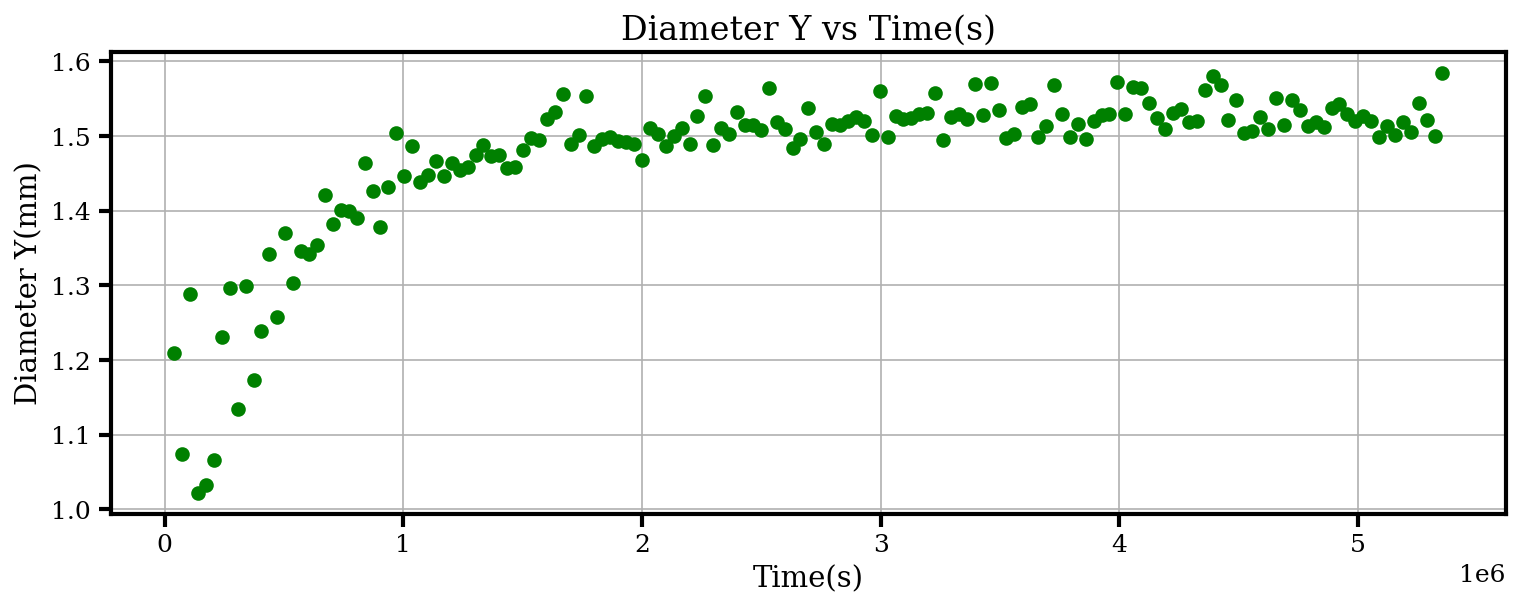

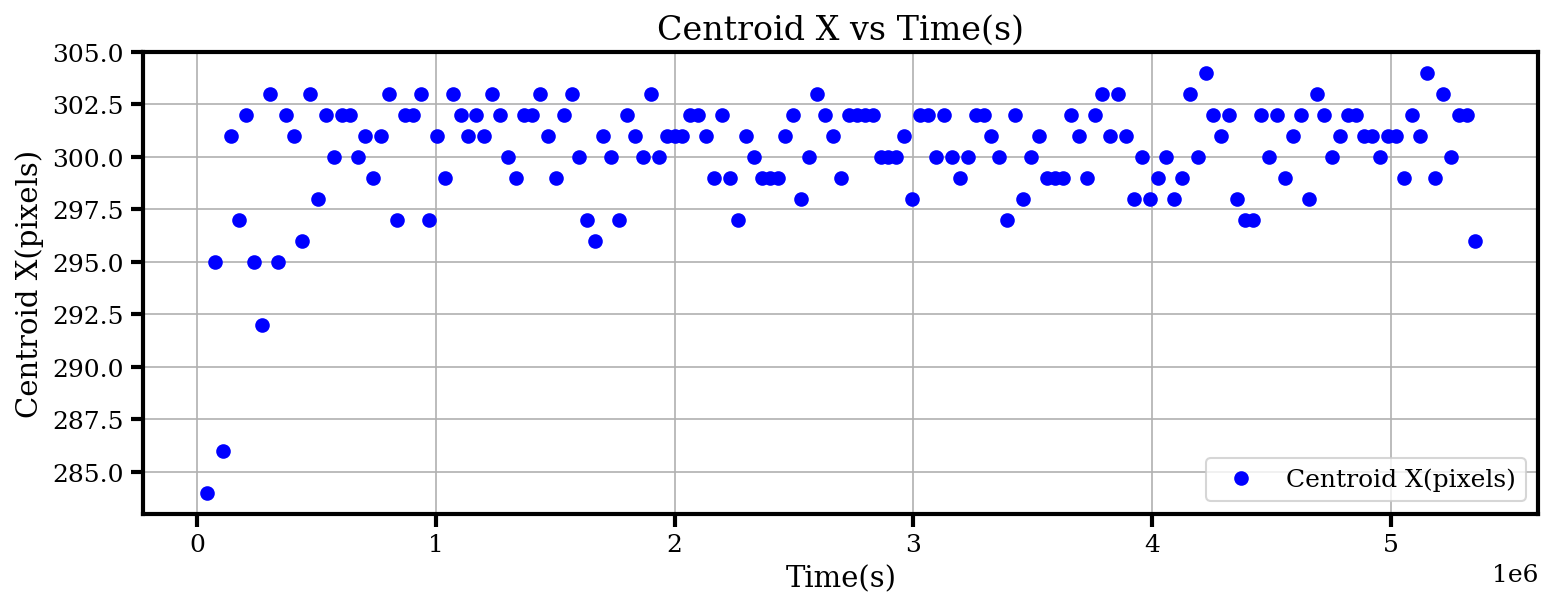

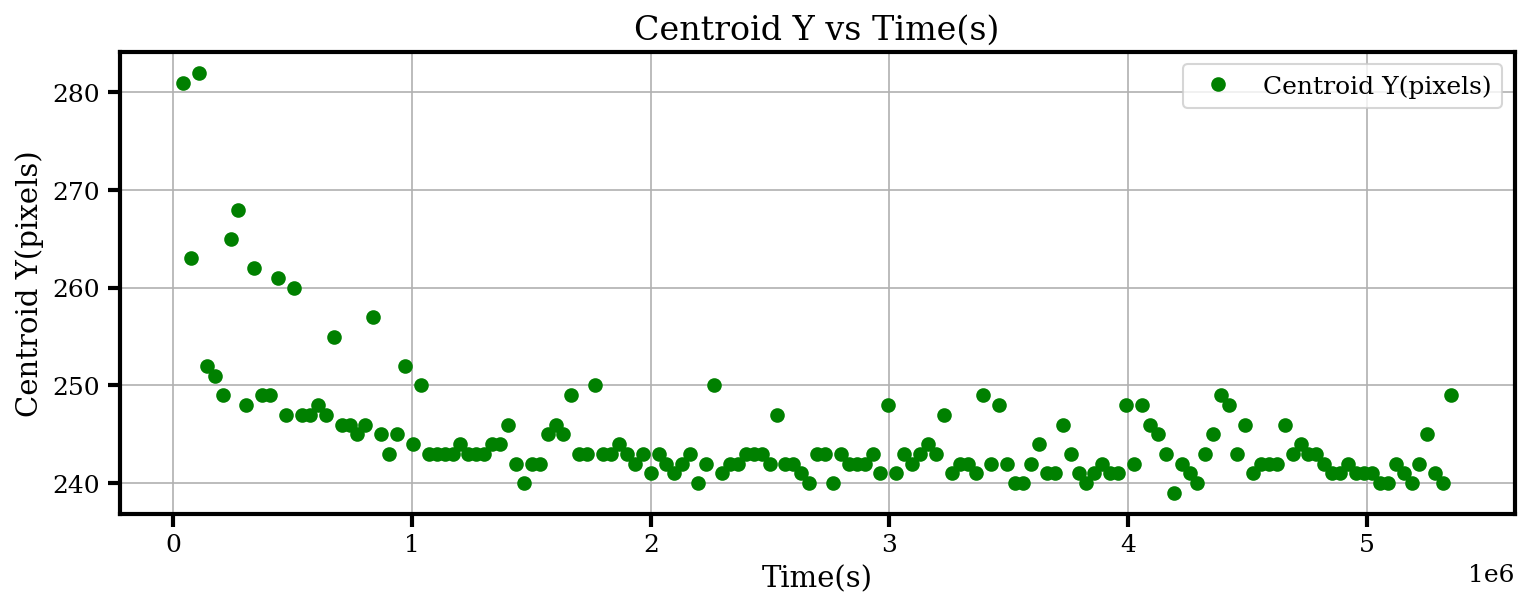

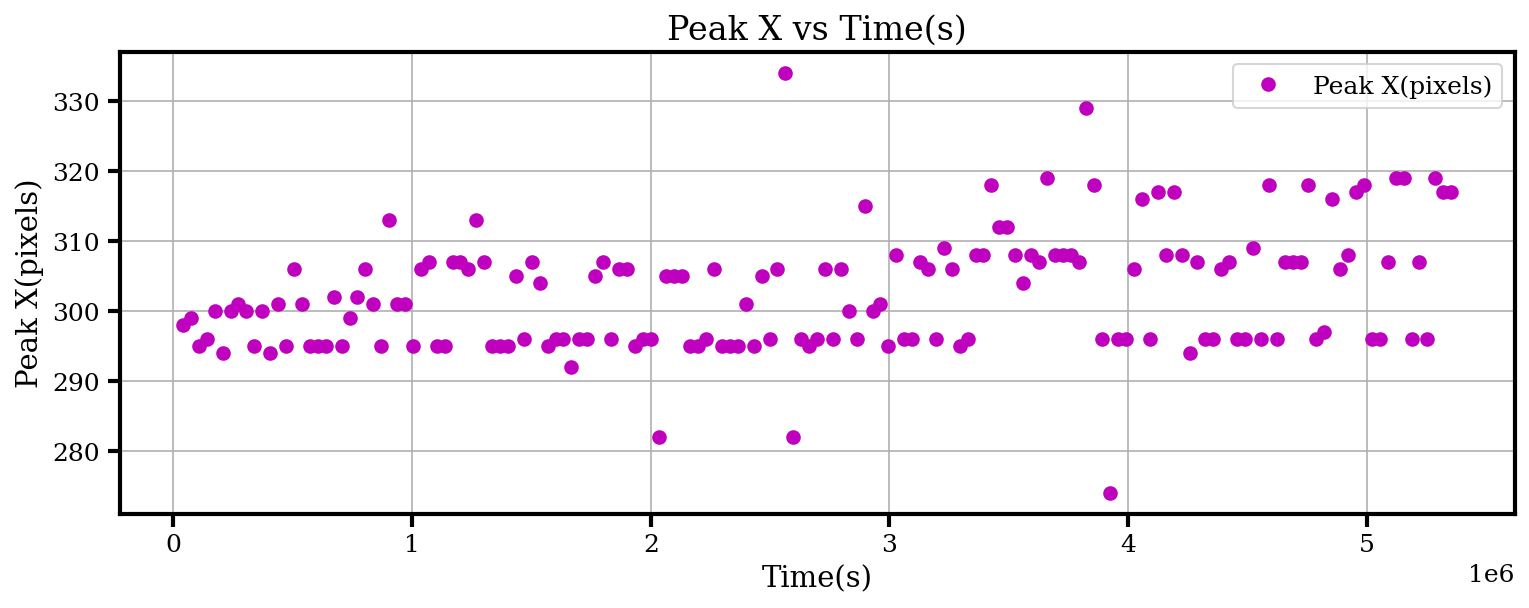

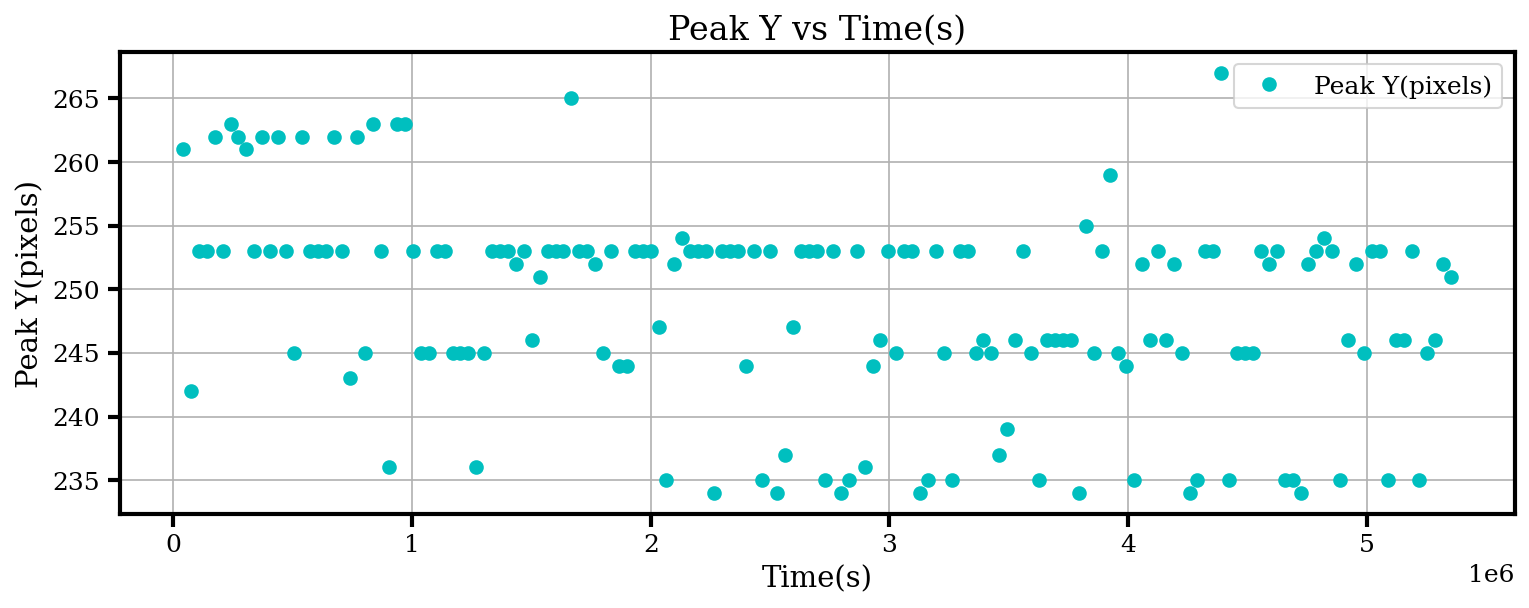

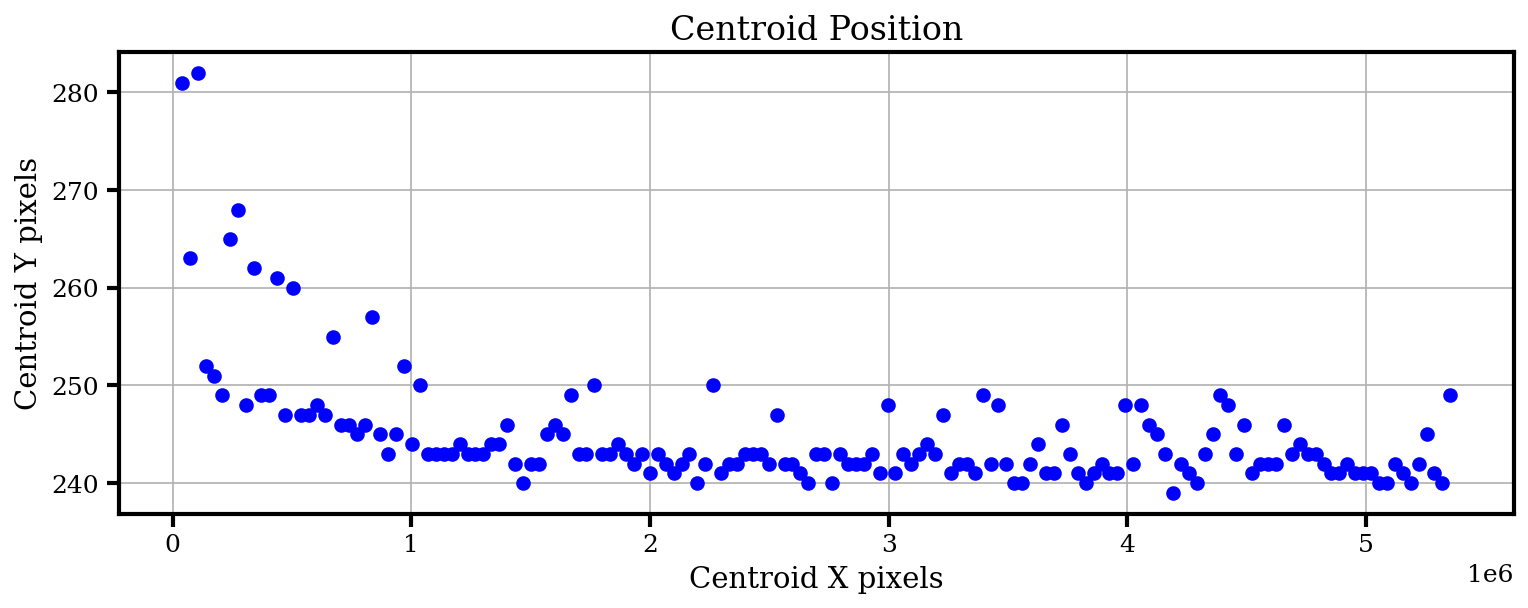

<Figure size 960x720 with 0 Axes>

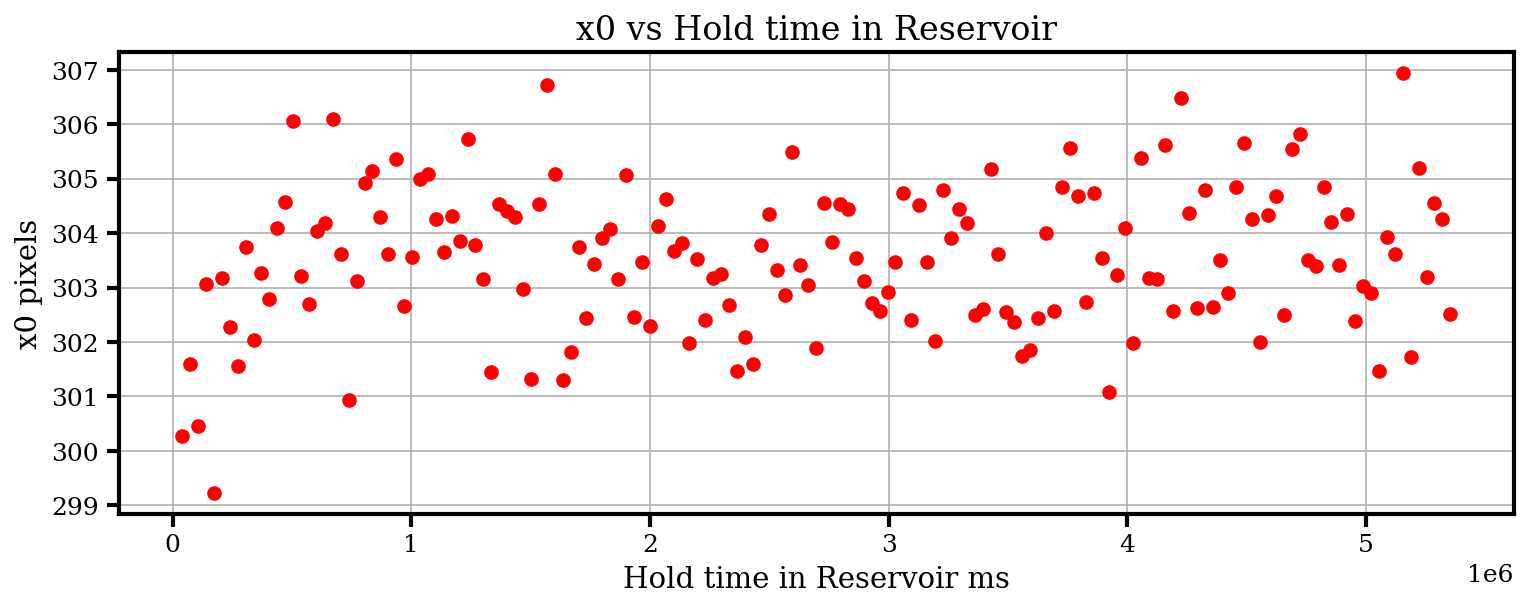

<Figure size 960x720 with 0 Axes>

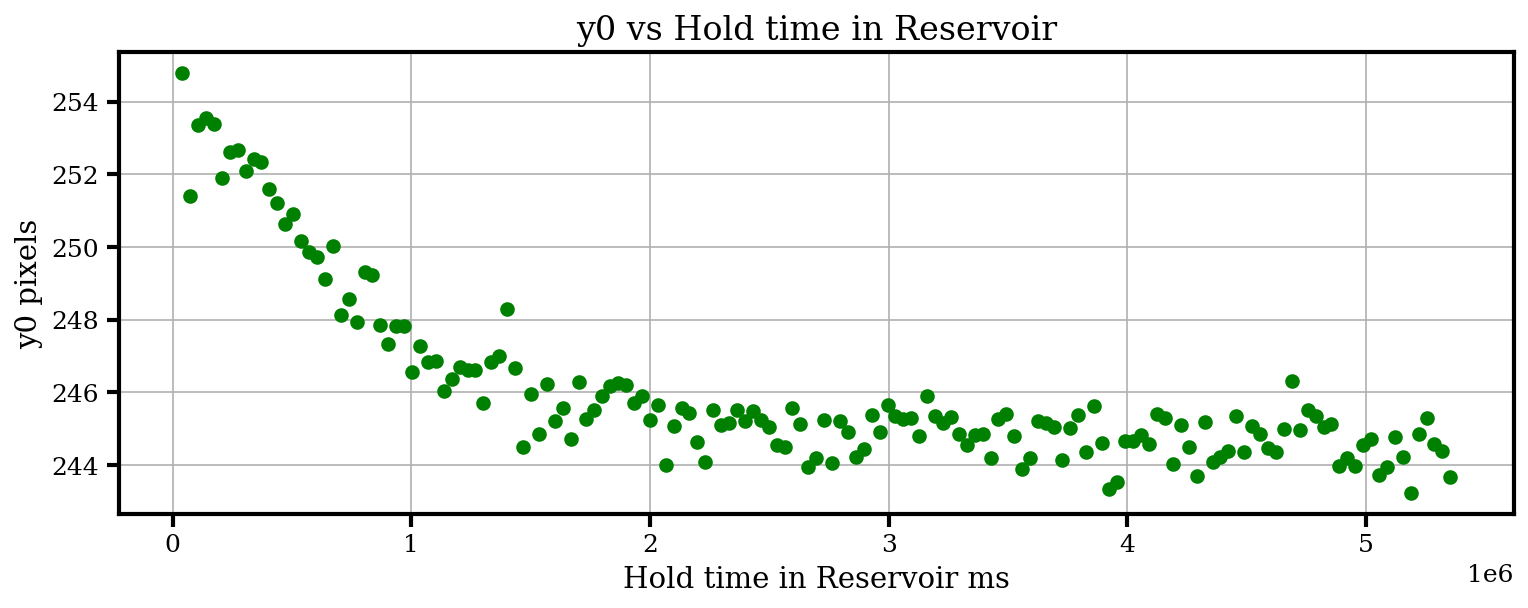

Phase Space Density data not available, skipping plot.


<Figure size 960x720 with 0 Axes>

In [271]:
# exposure time
from submodules.oitg.oitg.units import MHz


exposure_time = 0.03e-3

scaling_factor =22.36 * 1e-6  # Convert to meters, adjust scaling factor as needed

# add the exposure time to tof
# scan_params = scan_params + exposure_time

sx = np.array(sx)  * scaling_factor  # Convert to mm
sy = np.array(sy)  * scaling_factor  # Convert to mm

Γ_Rb = 6.065 * MHz

scan_params = f1["datasets"][d][()]
print(scan_params)
scan_params = np.array(scan_params)



# remobve the 7th data point from scan params
# scan_params = np.delete(scan_params, 6)

if e is not None:
    axis1_params = f1["datasets"][e][()]
    # print("coil_current:", axis1_params)


# plot the atom number vs the scan parameter (TOF)
def plot_atom_number_vs_scan_param(
    atom_number,
    scan_params,
    d,
    x_range=None,  # e.g. (0, 0.05)
    y_range=None,  # e.g. (1e7, 5e7)
):
    """
    Plot atom number vs scan parameter.

    Parameters:
    -----------
    atom_number : array-like
        Atom number data
    scan_params : array-like
        Scan parameter values (TOF)
    d : unused (kept for compatibility)
    x_range : tuple or None
        X-axis limits (xmin, xmax)
    y_range : tuple or None
        Y-axis limits (ymin, ymax)
    """

    # Delete first point
    atom_number = np.array(atom_number[1:])
    scan_params = np.array(scan_params[1:])

    print("after adding exposure time:", np.round(scan_params, 7))

    plt.figure(figsize=(12, 4))
    plt.plot(scan_params*1e3, atom_number, marker="o", linestyle="none", color="b")

    plt.xlabel("TOF (ms)")
    plt.ylabel("Atom Number")
    plt.title("Atom Number after PGC")
    plt.grid()

    # Apply x-axis range if provided
    if x_range is not None:
        plt.xlim(x_range)

    # Apply y-axis range if provided
    if y_range is not None:
        plt.ylim(y_range)
    else:
        plt.ylim(1e7, 1.2 * max(atom_number))  # default

    plt.show()
y_rangeY=max(atom_number) * 1.2
standard_deviation = np.std(atom_number)
print("Standard Deviation of Atom Number:", standard_deviation)
mean_atom_number = np.mean(atom_number)
print("Mean Atom Number:", mean_atom_number)
#lowest and highest atom number in exponential notation
lowest_atom_number = np.min(atom_number)
highest_atom_number = np.max(atom_number)
print("Lowest Atom Number:", lowest_atom_number)
print("Highest Atom Number:", highest_atom_number)
plot_atom_number_vs_scan_param(atom_number, scan_params, d, y_range=(0.01e7, y_rangeY))

#Bumber of bad data points in the atom number
thresold=0.6e8
#number of bad data points in the atom number
bad_data_points = sum(1 for x in atom_number if x < thresold)
print(f"Number of bad data points in the atom number: {bad_data_points}")

# plot the diameterx vs the scan parameter(TOF)
def plot_diameterx_vs_scan_param(diameterx, scan_params, d):
    """
    Plot diameterx vs scan parameter from the given HDF5 file.
    """
    # scan_params = f1["datasets"][d][()]

    # print(scan_params)
    # print(diameterx)
    plt.figure(figsize=(12, 4))
    plt.plot(
        scan_params * 1e3, diameterx * 1e3, marker="o", linestyle="none", color="r"
    )
    plt.xlabel("Time(s)")
    plt.ylabel("Diameter X(mm)")
    plt.title("Diameter X vs Time(s)")
    plt.grid()
    plt.show()


plot_diameterx_vs_scan_param(sx, scan_params, d)


def plot_diametery_vs_scan_param(diametery, scan_params, d):
    """
    Plot diametery vs scan parameter from the given HDF5 file.
    """

    plt.figure(figsize=(12, 4))
    plt.plot(
        scan_params * 1e3, diametery * 1e3, marker="o", linestyle="none", color="g"
    )
    plt.xlabel("Time(s)")
    plt.ylabel("Diameter Y(mm)")
    plt.title("Diameter Y vs Time(s)")
    plt.grid()
    plt.show()


plot_diametery_vs_scan_param(sy, scan_params, d)


def plot_centroid_vs_scan_param(centroidx, scan_params, d):
    """
    Plot centroid vs scan parameter from the given HDF5 file.
    """

    plt.figure(figsize=(12, 4))
    plt.plot(
        scan_params * 1e3,
        centroidx,
        marker="o",
        linestyle="none",
        color="b",
        label="Centroid X(pixels)",
    )
    plt.xlabel("Time(s)")
    plt.ylabel("Centroid X(pixels)")
    plt.title("Centroid X vs Time(s)")
    plt.legend()
    plt.grid()
    plt.show()


plot_centroid_vs_scan_param(centroidx, scan_params, d)


def plot_centroidy_vs_scan_param(centroidy, scan_params, d):
    """
    Plot centroidy vs scan parameter from the given HDF5 file.
    """
    # scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(12, 4))
    plt.plot(
        scan_params * 1e3,
        centroidy,
        marker="o",
        linestyle="none",
        color="g",
        label="Centroid Y(pixels)",
    )
    plt.xlabel("Time(s)")
    plt.ylabel("Centroid Y(pixels)")
    plt.title("Centroid Y vs Time(s)")
    plt.legend()
    plt.grid()
    plt.show()


plot_centroidy_vs_scan_param(centroidy, scan_params, d)


def plot_peak_vs_scan_param(peakx, scan_params, d):
    """
    Plot peak vs scan parameter from the given HDF5 file.
    """
    # scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(12, 4))
    plt.plot(
        scan_params * 1e3,
        peakx,
        marker="o",
        linestyle="none",
        color="m",
        label="Peak X(pixels)",
    )
    plt.xlabel("Time(s)")
    plt.ylabel("Peak X(pixels)")
    plt.title("Peak X vs Time(s)")
    plt.legend()
    plt.grid()
    plt.show()


plot_peak_vs_scan_param(peakx, scan_params, d)


def plot_peaky_vs_scan_param(peaky, scan_params, d):
    """
    Plot peaky vs scan parameter from the given HDF5 file.
    """
    # scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(12, 4))
    plt.plot(
        scan_params * 1e3,
        peaky,
        marker="o",
        linestyle="none",
        color="c",
        label="Peak Y(pixels)",
    )
    plt.xlabel("Time(s)")
    plt.ylabel("Peak Y(pixels)")
    plt.title("Peak Y vs Time(s)")
    plt.legend()
    plt.grid()
    plt.show()


plot_peaky_vs_scan_param(peaky, scan_params, d)


# make a plot function for general plotting with units specified
def plot_general(
    x,
    y,
    xlabel,
    ylabel,
    title,
    xunit="",
    yunit="",
    color="b",
    marker="o",
    linestyle="none",
    xlim=None,
    ylim=None,
):
    """
    General plotting function.
    """
    plt.figure(figsize=(12, 4))
    plt.plot(x, y, marker=marker, linestyle=linestyle, color=color)
    plt.xlabel(xlabel + " " + xunit)
    plt.ylabel(ylabel + " " + yunit)
    plt.title(title)
    plt.grid()
    plt.show()
    plt.gcf().tight_layout()


# plot centroid position
plot_general(
    scan_params * 1e3,
    centroidy,
    "Centroid X",
    "Centroid Y",
    "Centroid Position",
    xunit="pixels",
    yunit="pixels",
    color="b",
)

# PLOT x0 and scan parameter
plot_general(
    scan_params * 1e3,
    x0,
    "Hold time in Reservoir",
    "x0",
    "x0 vs Hold time in Reservoir",
    xunit="ms",
    yunit="pixels",
    color="r",
)

# PLOT y0 and scan parameter
plot_general(
    scan_params * 1e3,
    y0,
    "Hold time in Reservoir",
    "y0",
    "y0 vs Hold time in Reservoir",
    xunit="ms",
    yunit="pixels",
    color="g",
)

# plot phase space density vs scan parameter

if False:
    plot_general(
        scan_params * 1e3,
        phase_space_density_derived,
        "Hold time in Reservoir",
        "Phase Space Density Derived",
        "Phase Space Density vs Hold time in Reservoir",
        xunit="ms",
        yunit="",
        color="m",
    )

    # plot lamda db vs scan parameter
    plot_general(
        scan_params * 1e3,
        lambda_db_derived * 1e9,
        "Hold time in Reservoir",
        "Lambda db Derived",
        "Lambda db vs Hold time in Reservoir",
        xunit="ms",
        yunit="nm",
        color="c",
    )

    # plot number density vs scan parameter
    plot_general(
        scan_params * 1e3,
        number_density_derived,
        "Hold time in Reservoir",
        "Number Density Derived (atoms/m^3)",
        "Number Density vs Hold time in Reservoir",
        xunit="ms",
        yunit="atoms/m^3",
        color="y",
    )
else:
    print("Phase Space Density data not available, skipping plot.")

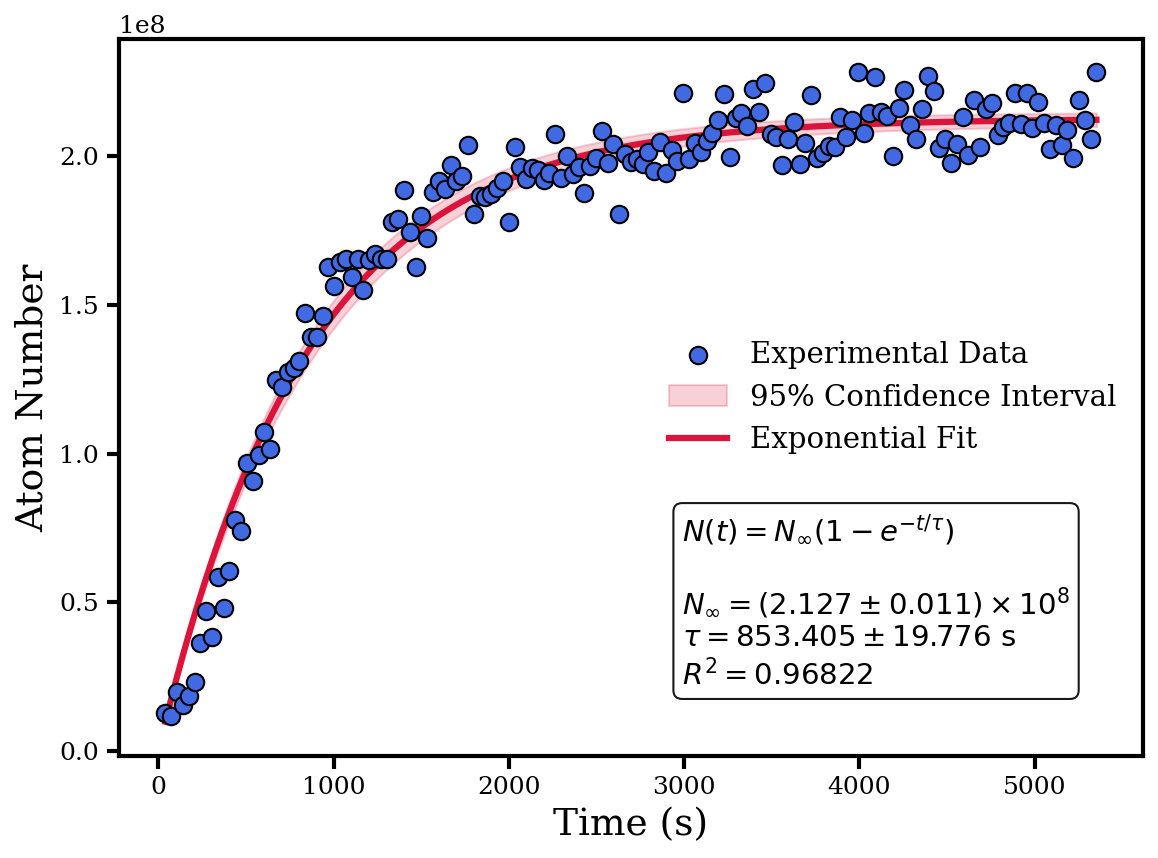


========== Fit Results ==========
Nss  = 2.12714e+08 ± 1.12517e+06
tau  = 853.40460 ± 19.77592 s
R²   = 0.968220

95% Confidence Intervals
Nss : [2.10492e+08, 2.14936e+08]
tau : [814.34723, 892.46197] s


In [272]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import t

# =====================================================
# Load your data here
# =====================================================
time = scan_params  # seconds
atom_number = atom_number  # atom number


# =====================================================
# Exponential Loading Function
# N(t)=Nss*(1-exp(-t/tau))
# =====================================================
def loading_model(t, Nss, tau):
    return Nss * (1 - np.exp(-t / tau))


# =====================================================
# Initial Guess
# =====================================================
guess = [np.max(atom_number), 2]

# =====================================================
# Curve Fit
# =====================================================
popt, pcov = curve_fit(loading_model, time, atom_number, p0=guess)

Nss, tau = popt
err = np.sqrt(np.diag(pcov))
Nss_err, tau_err = err

# =====================================================
# Goodness of Fit (R²)
# =====================================================
fit = loading_model(time, *popt)

residuals = atom_number - fit
ss_res = np.sum(residuals**2)
ss_tot = np.sum((atom_number - np.mean(atom_number)) ** 2)
R2 = 1 - ss_res / ss_tot

# =====================================================
# Smooth Fit Curve
# =====================================================
t_fit = np.linspace(np.min(time), np.max(time), 500)
N_fit = loading_model(t_fit, *popt)

# =====================================================
# 95% Confidence Interval
# =====================================================

# Jacobian matrix
J = np.zeros((len(t_fit), len(popt)))

# dN/dNss
J[:, 0] = 1 - np.exp(-t_fit / tau)

# dN/dtau
J[:, 1] = Nss * np.exp(-t_fit / tau) * (t_fit / tau**2)

# Standard error of fitted curve
fit_var = np.einsum("ij,jk,ik->i", J, pcov, J)
fit_std = np.sqrt(fit_var)

# Student's t-value (95% confidence)
dof = max(0, len(time) - len(popt))
tval = t.ppf(0.975, dof)

lower = N_fit - tval * fit_std
upper = N_fit + tval * fit_std

# =====================================================
# Plot Settings
# =====================================================
plt.rcParams.update({
    "font.size": 16,
    "axes.linewidth": 2,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "font.family": "serif",
})

fig, ax = plt.subplots(figsize=(8, 6))

# Data
ax.scatter(
    time,
    atom_number,
    s=70,
    color="royalblue",
    edgecolor="black",
    label="Experimental Data",
    zorder=3,
)

# Confidence Interval
ax.fill_between(
    t_fit,
    lower,
    upper,
    color="crimson",
    alpha=0.20,
    label="95% Confidence Interval",
    zorder=1,
)

# Fit
ax.plot(t_fit, N_fit, color="crimson", linewidth=3, label="Exponential Fit", zorder=2)

# Labels
ax.set_xlabel("Time (s)", fontsize=18)
ax.set_ylabel("Atom Number", fontsize=18)

# =====================================================
# Parameter Box
# =====================================================
text = (
    r"$N(t)=N_{\infty}(1-e^{-t/\tau})$"
    "\n\n"
    f"$N_{{\\infty}} = ({Nss / 1e8:.3f}\\pm{Nss_err / 1e8:.3f})\\times10^8$"
    "\n"
    f"$\\tau = {tau:.3f}\\pm{tau_err:.3f}\\ {{\\rm s}}$"
    "\n"
    f"$R^2 = {R2:.5f}$"
)

ax.text(
    0.55,
    0.10,
    text,
    transform=ax.transAxes,
    fontsize=14,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.9),
)

# Legend
ax.legend(frameon=False, fontsize=14)

# Nice layout
plt.tight_layout()

# =====================================================
# Save High Quality Figures
# =====================================================
plt.savefig("Atom_Loading_Fit.png", dpi=600, bbox_inches="tight")
plt.savefig("Atom_Loading_Fit.pdf", bbox_inches="tight")

plt.show()

# =====================================================
# Print Results
# =====================================================
print("\n========== Fit Results ==========")
print(f"Nss  = {Nss:.5e} ± {Nss_err:.5e}")
print(f"tau  = {tau:.5f} ± {tau_err:.5f} s")
print(f"R²   = {R2:.6f}")

print("\n95% Confidence Intervals")
print(f"Nss : [{Nss - tval * Nss_err:.5e}, {Nss + tval * Nss_err:.5e}]")
print(f"tau : [{tau - tval * tau_err:.5f}, {tau + tval * tau_err:.5f}] s")


TOF data: [  40.04289051   73.25261288  106.46954456  139.68736886  172.90209287
  206.1167114   239.31160147  272.49073755  305.74404064  338.95509974
  372.15846933  405.41307921  438.64399705  471.85368043  505.05615791
  538.478125    571.69672149  604.90807286  638.11984046  671.33541944
  704.55114254  737.76737838  770.98071209  804.20308496  837.41488207
  870.62334699  903.82915346  937.03956239  970.23658701 1003.44406554
 1036.64804179 1069.84452961 1103.04135393 1136.25201519 1169.43550241
 1202.63225301 1235.8243513  1269.02265109 1302.20835971 1335.39908631
 1368.59749407 1401.80273874 1435.00239223 1468.20812742 1501.40076433
 1534.60465963 1567.82465504 1601.02519276 1634.27786362 1667.47329404
 1700.67875945 1733.88036111 1767.06017358 1800.25396495 1833.4551089
 1866.66523124 1899.86405333 1933.07192443 1966.28246711 1999.47222577
 2032.66860092 2065.86455878 2099.05568232 2132.24506721 2165.4460277
 2198.64293557 2231.84701821 2265.04419371 2298.2476388  2331.4410359

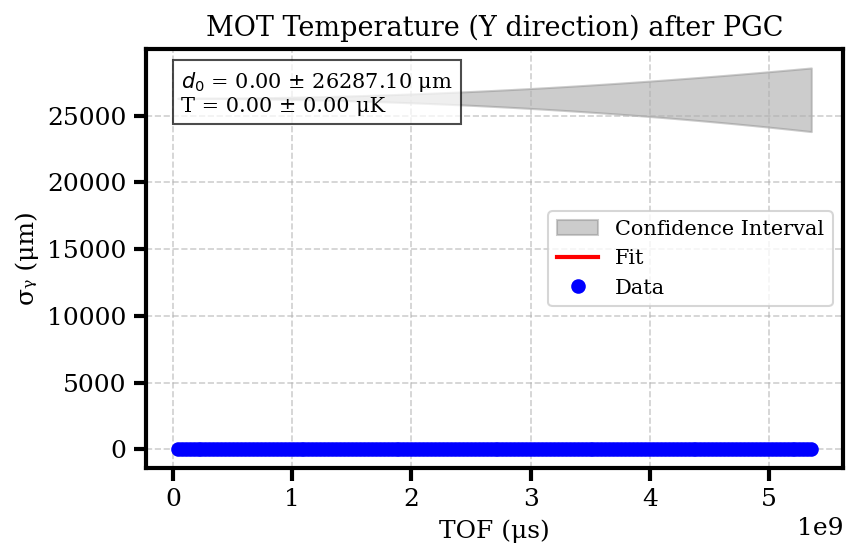

d0 = 0.000000 ± 26287.099911 μm
T  = 0.000000 ± 0.000000 μK
Final T with pixel size uncertainty: 0.000000 ± 0.000000 μK
New minimum T error: 3.42e-15 with p0 = [5e-06, 1e-06]


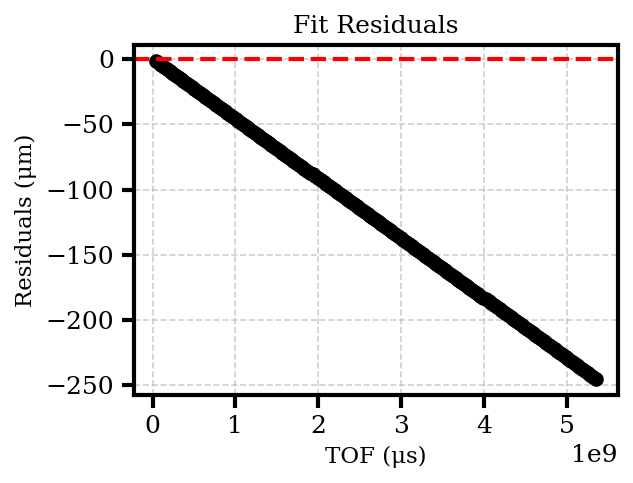

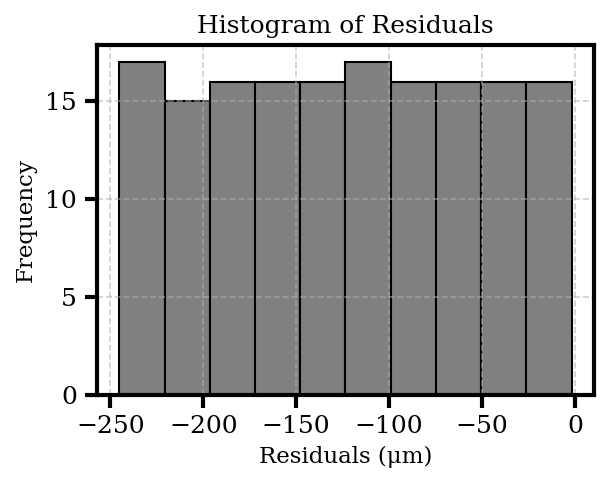

In [273]:
# curve fitting to find the diameter as a function of time of flight (TOF)
import numpy as np

t_data = scan_params  # TOF data
d_data = np.array(sy)  # Diameter data, using sx as an e


sacling_factor = 1  # Convert to meters, adjust scaling factor as needed
diametertype = "y"  # Change to "x" or "y" based on which diameter you want to fit

print("TOF data:", t_data)
print("Diameter data:", d_data)

# increasing order t data
t_data_sorted = np.sort(t_data)
print("Sorted TOF data:", t_data_sorted)


# return index of some value in t_data_sorted
def get_index_of_value(value, t_data_sorted):
    try:
        return np.where(t_data_sorted == value)[0][0]
    except IndexError:
        return -1


ind = get_index_of_value(t_data_sorted[0], t_data)

# diameter data sorted
d_data_sorted = d_data[np.argsort(t_data)]
print("Sorted Diameter data:", d_data_sorted)
# d_data_sorted = (
#    d_data_sorted * scaling_factor
# )  # Convert to meters, adjust scaling factor as needed
print("Sorted Diameter data (meters):", d_data_sorted)
d_data_sorted = d_data_sorted * scaling_factor  # Convert to meters for fitting

# remove first five points from t_data_sorted and d_data_sorted
#t_data_sorted = t_data_sorted[1:]
#d_data_sorted = d_data_sorted[1:]


# --- Constants ---
kB = 1.380649e-23  # Boltzmann constant (J/K)
m = 1.45e-25  # Mass (kg)
s = 25  # Pixel size in µm/pixel
delta_s = 0.18  # Uncertainty in pixel size


# --- Model function ---
def model(t, d0, T):
    return np.sqrt(d0**2 + (kB * T * t**2) / m)


# --- Fit the data ---
# NOTE: Replace or define your t_data_sorted and d_data_sorted arrays before fitting.
# Example:
# t_data_sorted = np.array([...])

bounds = ([0, 0], [np.inf, np.inf])
p0 = [1e-3, 50e-6]  # Initial guess

popt, pcov = curve_fit(model, t_data_sorted, d_data_sorted, p0=p0, bounds=bounds)
d0_fit, T_fit = popt
d0_err, T_err = np.sqrt(np.diag(pcov))

# --- Combined Plot: Data + Fit + Confidence Interval ---
plt.figure(figsize=(6, 4))

t_fit = np.linspace(min(t_data_sorted), max(t_data_sorted), 300)
d_fit = model(t_fit, *popt)
perr = np.sqrt(np.diag(pcov))
d_fit_upper = model(t_fit, *(popt + perr))
d_fit_lower = model(t_fit, *(popt - perr))

plt.fill_between(
    t_fit * 1e6,
    d_fit_lower * 1e6,
    d_fit_upper * 1e6,
    color="gray",
    alpha=0.4,
    label="Confidence Interval",
)
plt.plot(t_fit * 1e6, d_fit * 1e6, "r-", label="Fit")
plt.plot(t_data_sorted * 1e6, d_data_sorted * 1e6, "o", color="blue", label="Data")

plt.xlabel("TOF (μs)", fontsize=12)
ylabel = (
    "σₓ (μm)"
    if diametertype == "x"
    else "σᵧ (μm)"
    if diametertype == "y"
    else "Diameter (μm)"
)
plt.ylabel(ylabel, fontsize=12)

if diametertype == "x":
    plt.title("MOT Temperature (X direction) after PGC", fontsize=13)
elif diametertype == "y":
    plt.title("MOT Temperature (Y direction) after PGC", fontsize=13)
else:
    plt.title("MOT Temperature Fit", fontsize=13)

fit_text = (
    f"$d_0$ = {d0_fit * 1e6:.2f} ± {d0_err * 1e6:.2f} μm\n"
    f"T = {T_fit * 1e6:.2f} ± {T_err * 1e6:.2f} μK"
)
plt.gca().text(
    0.05,
    0.95,
    fit_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7),
)

plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Output Fit Results ---
print(f"d0 = {d0_fit * 1e6:.6f} ± {d0_err * 1e6:.6f} μm")
print(f"T  = {T_fit * 1e6:.6f} ± {T_err * 1e6:.6f} μK")

# --- Uncertainty due to pixel size ---
delta_T_pixel = T_fit * 2 * (delta_s / s)
delta_T_total = np.sqrt(T_err**2 + delta_T_pixel**2)
print(
    f"Final T with pixel size uncertainty: {T_fit * 1e6:.6f} ± {delta_T_total * 1e6:.6f} μK"
)

# --- Parameter scan to minimize T error ---
min_error = float("inf")
best_p0 = None
for d0_guess in np.linspace(5e-6, 50e-6, 10):
    for T_guess in np.linspace(1e-6, 20e-6, 10):
        try:
            p0_test = [d0_guess, T_guess]
            popt_test, pcov_test = curve_fit(
                model, t_data_sorted, d_data_sorted, p0=p0_test, bounds=bounds
            )
            T_err_test = np.sqrt(np.diag(pcov_test))[1]
            if T_err_test < min_error:
                min_error = T_err_test
                best_p0 = p0_test
                print(f"New minimum T error: {min_error:.2e} with p0 = {p0_test}")
        except Exception:
            continue

# --- Residuals Plot ---
residuals = d_data_sorted - model(t_data_sorted, *popt)

plt.figure(figsize=(4.5, 3.5))
plt.plot(t_data_sorted * 1e6, residuals * 1e6, "o", color="black")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("TOF (μs)", fontsize=11)
plt.ylabel("Residuals (μm)", fontsize=11)
plt.title("Fit Residuals", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Histogram of Residuals ---
plt.figure(figsize=(4.5, 3.5))
plt.hist(residuals * 1e6, bins=10, edgecolor="black", color="gray")
plt.xlabel("Residuals (μm)", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.title("Histogram of Residuals", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Pixel data: [254.79045422 251.40227541 253.34512473 253.54679216 253.39193886
 251.90325267 252.60068097 252.66541028 252.10389583 252.4329763
 252.34623856 251.60579735 251.20322797 250.64600147 250.90164893
 250.16204009 249.87060944 249.71730039 249.12612523 250.02883029
 248.11894973 248.57009655 247.94370996 249.32524364 249.24233194
 247.85294179 247.3261371  247.82810179 247.82617603 246.54924707
 247.2838145  246.82395655 246.85093267 246.03662798 246.37547586
 246.70946772 246.61281876 246.60736271 245.71431033 246.82745269
 247.01015315 248.28399513 246.6633201  244.49330838 245.96203779
 244.86189186 246.24458857 245.21656179 245.58095917 244.72523376
 246.28324548 245.26973713 245.52463473 245.88845491 246.17637676
 246.24569042 246.20588016 245.709939   245.89403916 245.23355586
 245.64481956 244.00686109 245.06588417 245.58462774 245.42293775
 244.63396099 244.09618256 245.52341961 245.10504118 245.16560652
 245.509277   245.21489339 245.49561994 245.23134717 245.05848325

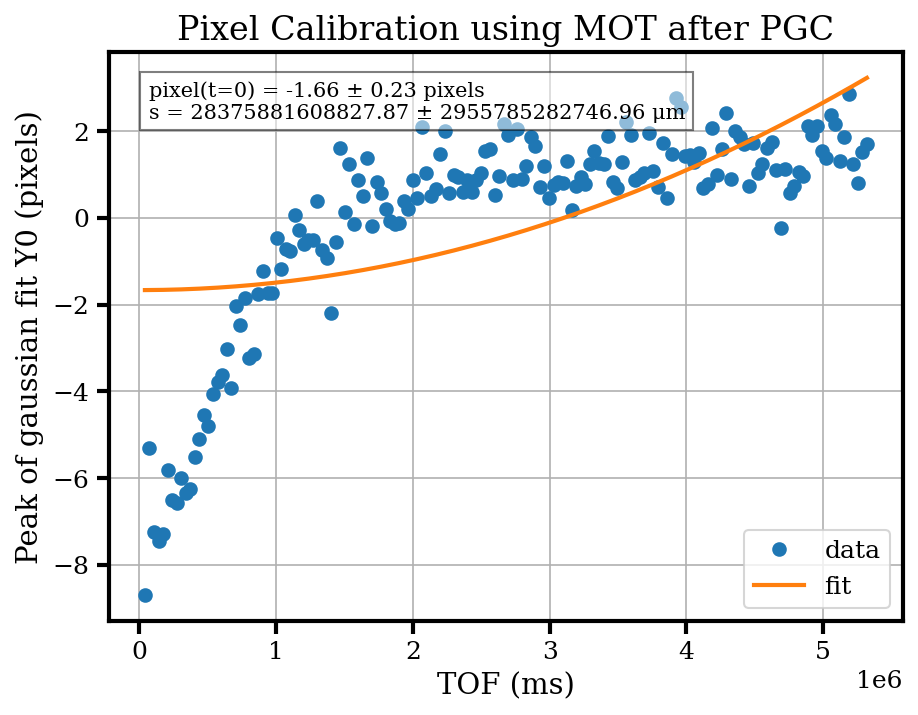

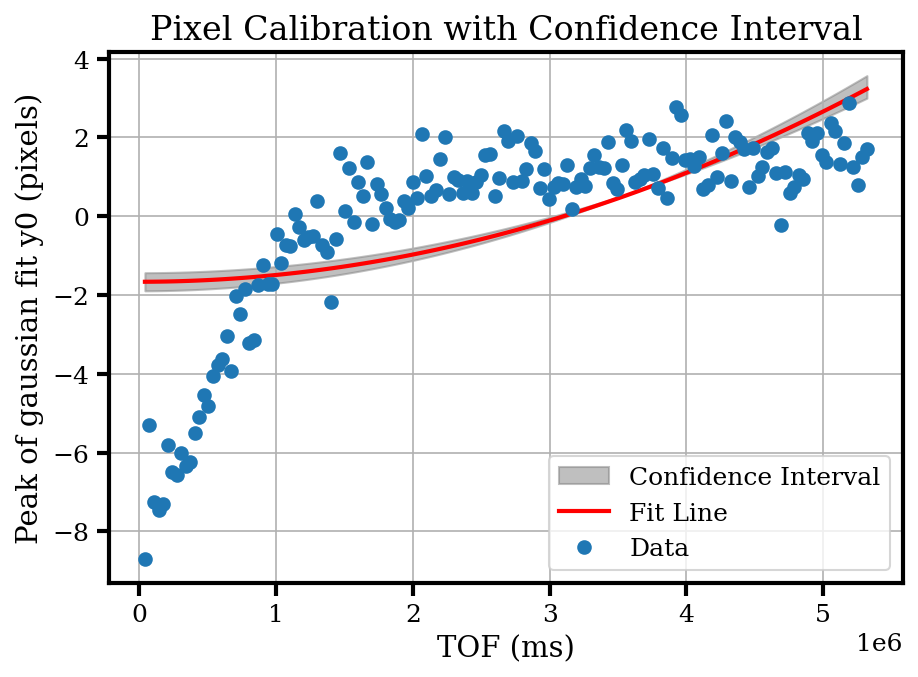

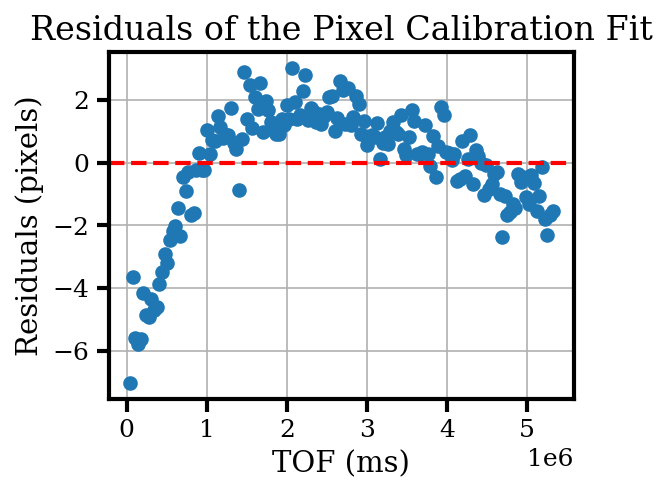

In [274]:
# pixel calibration fit
g = 9.81  # m/s^2, gravitational acceleration

pixel_number_vertical_data = np.array(y0)  # Pixel data, using x0 as an example
print("Pixel data:", pixel_number_vertical_data)

print("TOF data:", t_data)


# increasing order t data
t_data_sorted = np.sort(t_data)
print("Sorted TOF data:", t_data_sorted)


# return index of some value in t_data_sorted
def get_index_of_value(value, t_data_sorted):
    try:
        return np.where(t_data_sorted == value)[0][0]
    except IndexError:
        return -1


# pixel data sorted
pixel_data_sorted = pixel_number_vertical_data[np.argsort(t_data)]
print("Sorted Pixel data:", pixel_data_sorted)

pixel_data_sorted = -(pixel_data_sorted - np.mean(pixel_data_sorted))

# remove last data point
pixel_data_sorted = pixel_data_sorted[:-1]
t_data_sorted = t_data_sorted[:-1]



def model_pixel_calibration(t, y0, s):
    return y0 + (1 / 2) * t**2 * g / s


# Initial GUESS
y0_initial = 0
s_initial = 2e-6


# Fit your existing data
popt_pixel, pcov_pixel = curve_fit(
    model_pixel_calibration,
    t_data_sorted,
    pixel_data_sorted,
    p0=[y0_initial, s_initial],
)
y0_fit = popt_pixel[0]
y0_err = np.sqrt(np.diag(pcov_pixel))[0]
s_fit = popt_pixel[1]
s_err = np.sqrt(np.diag(pcov_pixel))[1]

# Print results
print(f"y0 = {y0_fit:.7f} ± {y0_err:.7f} pixels")
print(f"s = {s_fit * 1e6:.7f} ± {s_err * 1e6:.7f} μm")


# Plot pixel calibration
plt.plot(t_data_sorted * 1e3, pixel_data_sorted, "o", label="data")
plt.plot(
    t_data_sorted * 1e3,
    model_pixel_calibration(t_data_sorted, *popt_pixel),
    label="fit",
)
plt.xlabel("TOF (ms)")
plt.ylabel("Peak of gaussian fit Y0 (pixels)")
plt.legend()
plt.grid(True)

fit_text = (
    f"pixel(t=0) = {y0_fit:.2f} ± {y0_err:.2f} pixels\ns = {s_fit * 1e6:.2f} ±"
    f" {s_err * 1e6:.2f} μm"
)
plt.gca().text(
    0.05,
    0.95,
    fit_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="black"),
)
plt.tight_layout()
plt.title("Pixel Calibration using MOT after PGC")
plt.show()


# confidence interval for pixel calibration
# Calculate the standard deviation of the fit
perr_pixel = np.sqrt(np.diag(pcov_pixel))
# Generate points for the fit line
t_fit_pixel = np.linspace(min(t_data_sorted), max(t_data_sorted), 100)
pixel_fit = model_pixel_calibration(t_fit_pixel, *popt_pixel)
# Calculate the upper and lower bounds of the confidence interval
pixel_fit_upper = model_pixel_calibration(t_fit_pixel, *(popt_pixel + perr_pixel))
pixel_fit_lower = model_pixel_calibration(t_fit_pixel, *(popt_pixel - perr_pixel))
# Plot the fit line and confidence interval
plt.fill_between(
    t_fit_pixel * 1e3,
    pixel_fit_lower,
    pixel_fit_upper,
    color="gray",
    alpha=0.5,
    label="Confidence Interval",
)
plt.plot(t_fit_pixel * 1e3, pixel_fit, "r-", label="Fit Line")
plt.plot(t_data_sorted * 1e3, pixel_data_sorted, "o", label="Data")
plt.xlabel("TOF (ms)")
plt.ylabel("Peak of gaussian fit y0 (pixels)")
plt.title("Pixel Calibration with Confidence Interval")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# plot the residuals of the pixel calibration
residuals_pixel = pixel_data_sorted - model_pixel_calibration(
    t_data_sorted, *popt_pixel
)
plt.figure(figsize=(4, 3))
plt.plot(t_data_sorted * 1e3, residuals_pixel, "o")
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("TOF (ms)")
plt.ylabel("Residuals (pixels)")
plt.title("Residuals of the Pixel Calibration Fit")
plt.grid()
plt.show()


Fitted parameters:
A = 0.0096, b = 7.9159, ω = 1.0003, φ = 0.0000, C = 0.0015
Estimated frequency: 0.1592 Hz


/tmp/ipykernel_120291/922274678.py:26: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(decaying_sine, t_data_sorted, d_data_sorted, p0=initial_guess)


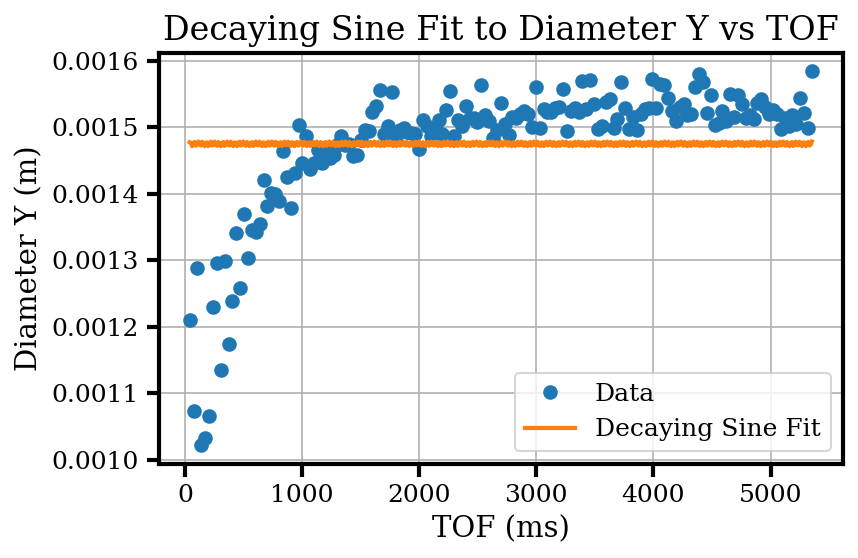

In [275]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Assuming scan_params = t_data and sy = d_data
t_data = scan_params  # Time-of-flight data
d_data = np.array(sy)  # Diameter data

# Sort the time and corresponding diameter values
t_data_sorted = np.sort(t_data)
d_data_sorted = d_data[np.argsort(t_data)]

# remove 4th point from data_sorted and t_data_sorted
# t_data_sorted = np.delete(t_data_sorted, [3, 10])
# d_data_sorted = np.delete(d_data_sorted, [3, 10])


def decaying_sine(t, A, b, omega, phi, C):
    return A * np.exp(-b) * np.sin(omega * t + phi) + C


# Initial guess: [amplitude, decay rate, angular frequency, phase, offset]
initial_guess = [1000, 0.0, 1.0, 0.0, 0.0]


popt, pcov = curve_fit(decaying_sine, t_data_sorted, d_data_sorted, p0=initial_guess)
A_fit, b_fit, omega_fit, phi_fit, C_fit = popt

# ⚡ Frequency (Hz) is: f = omega / (2π)
frequency_hz = omega_fit / (2 * np.pi)

print("Fitted parameters:")
print(
    f"A = {A_fit:.4f}, b = {b_fit:.4f}, ω = {omega_fit:.4f}, φ = {phi_fit:.4f}, C = {C_fit:.4f}"
)
print(f"Estimated frequency: {frequency_hz:.4f} Hz")


t_fit = np.linspace(min(t_data), max(t_data), 500)
d_fit = decaying_sine(t_fit, *popt)

plt.figure(figsize=(6, 4))
plt.plot(t_data_sorted, d_data_sorted, "o", label="Data")
plt.plot(t_fit, d_fit, "-", label="Decaying Sine Fit")
plt.xlabel("TOF (ms)")
plt.ylabel("Diameter Y (m)")
plt.title("Decaying Sine Fit to Diameter Y vs TOF")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

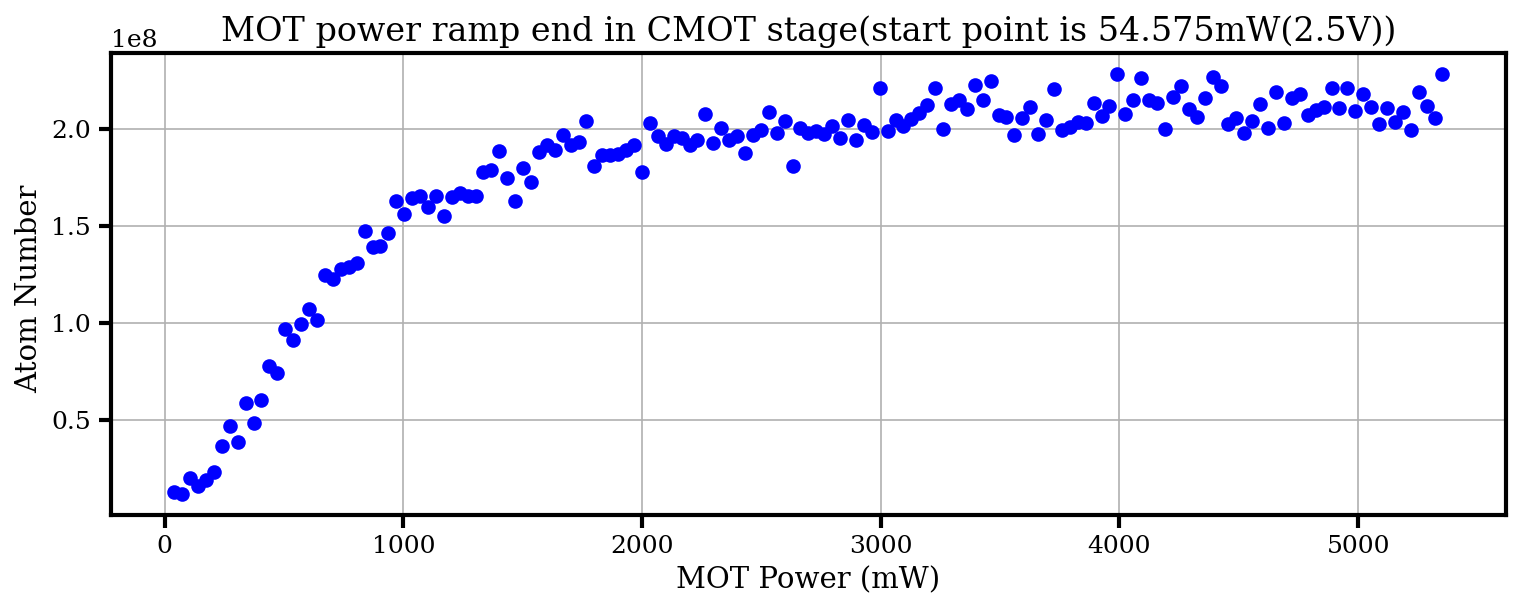

<Figure size 960x720 with 0 Axes>

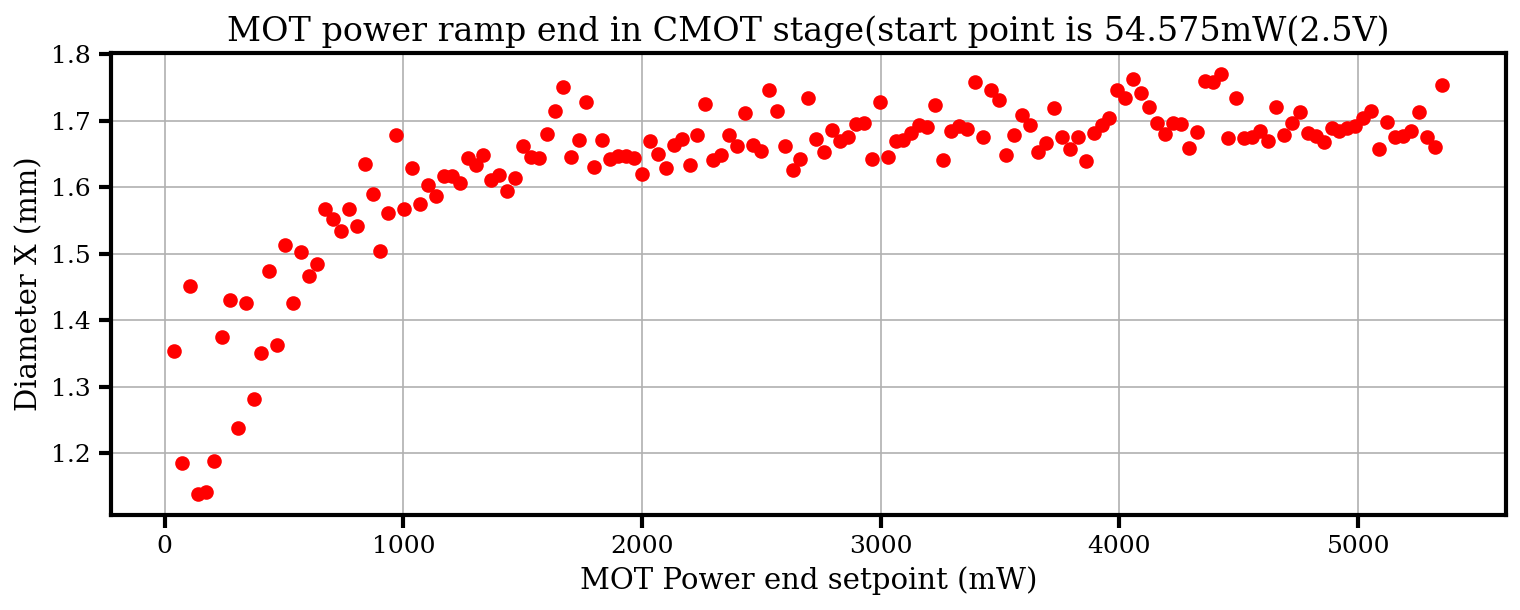

<Figure size 960x720 with 0 Axes>

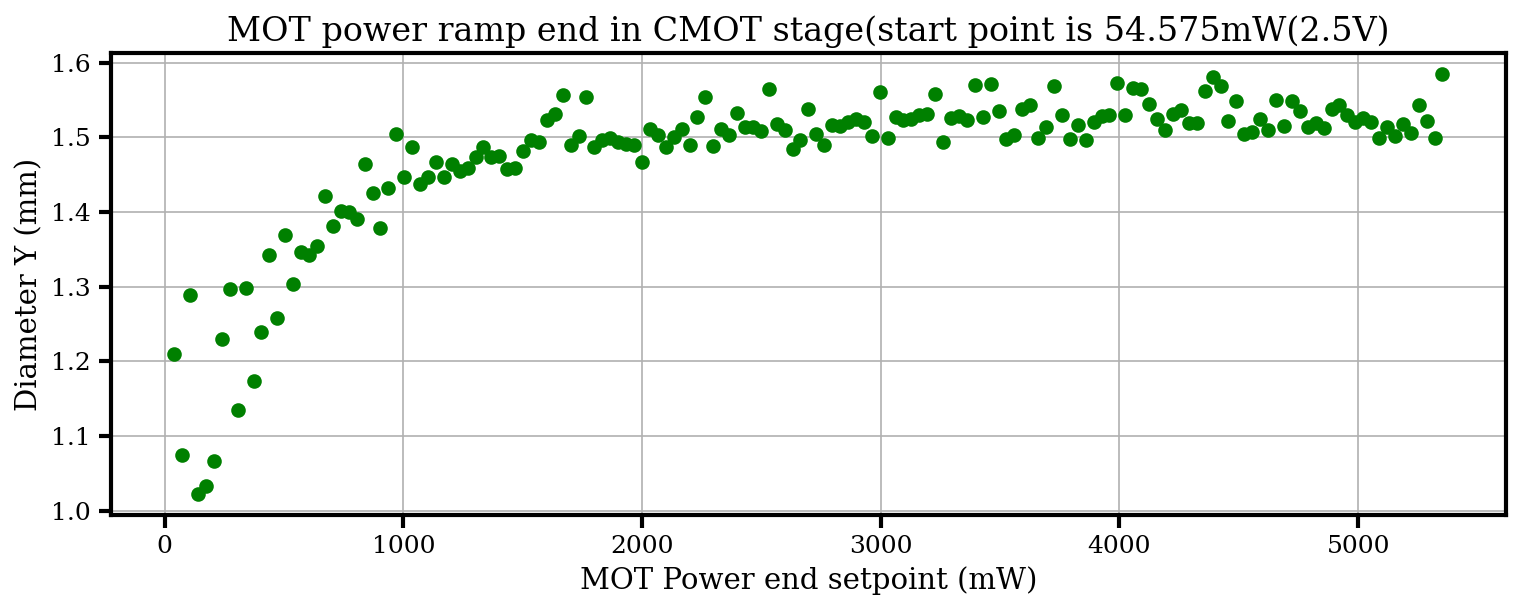

<Figure size 960x720 with 0 Axes>

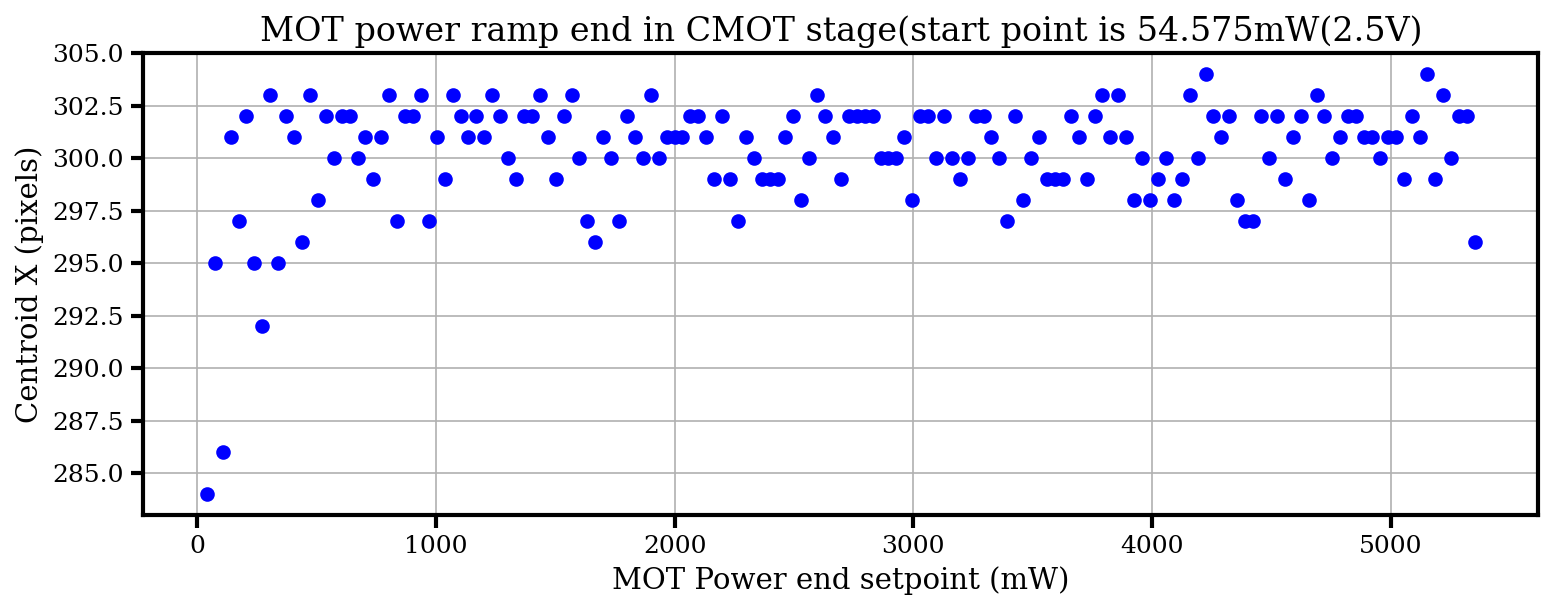

<Figure size 960x720 with 0 Axes>

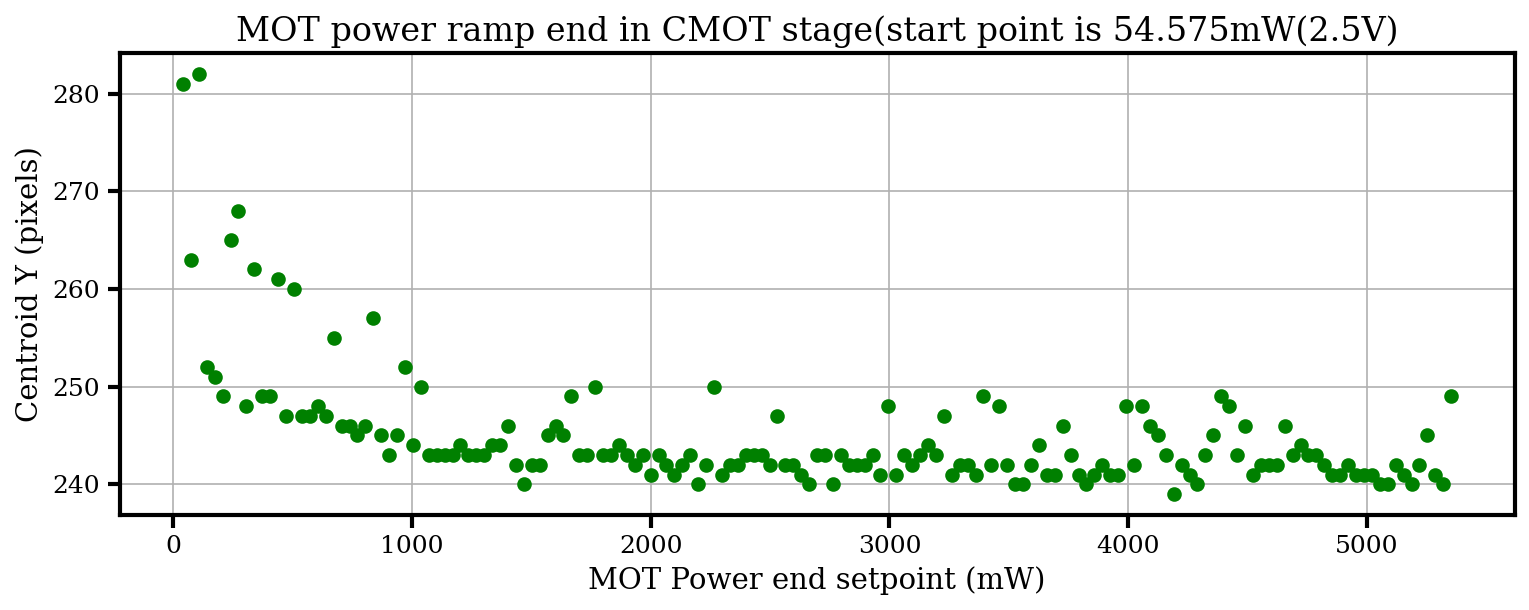

<Figure size 960x720 with 0 Axes>

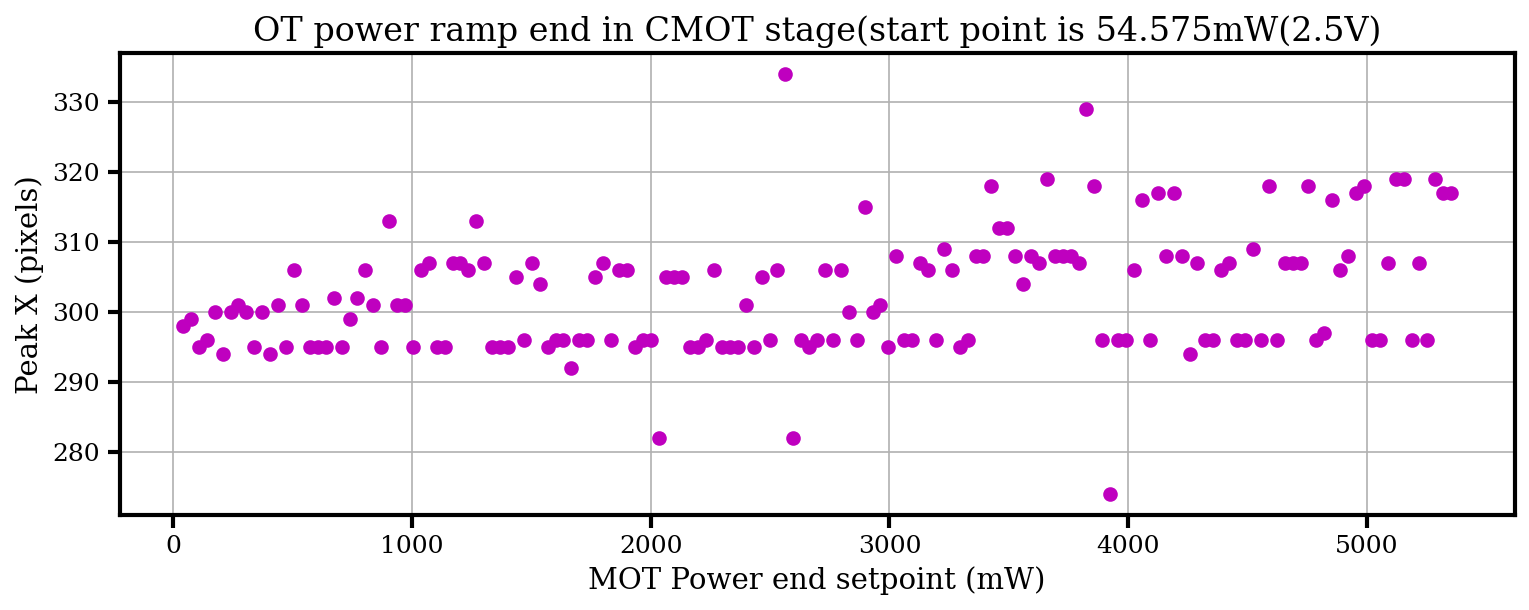

<Figure size 960x720 with 0 Axes>

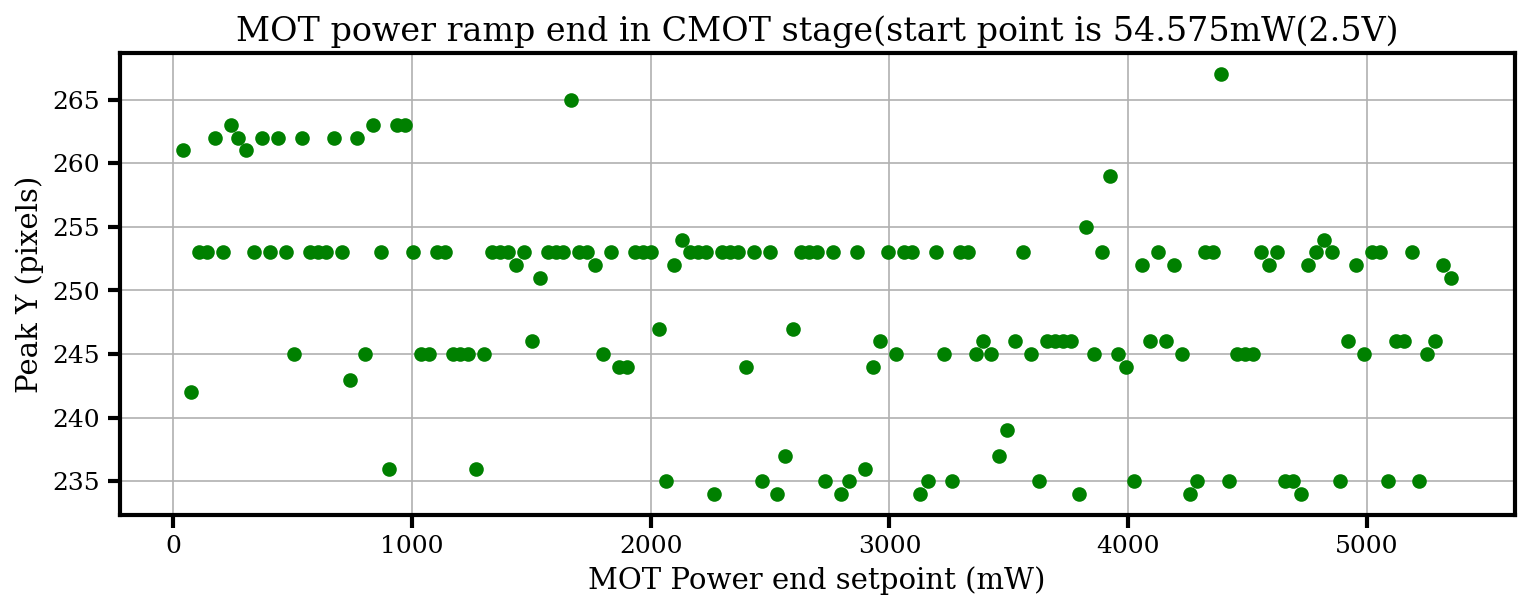

<Figure size 960x720 with 0 Axes>

In [276]:
scan_params = scan_params

# plot atom number vs coil current
plot_general(
    scan_params,
    atom_number,
    "MOT Power",
    "Atom Number",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V))",
    xunit="(mW)",
    yunit="",
    color="b",
)

# plot all other parameters vs coil current
plot_general(
    scan_params,
    sx * 1e3,
    "MOT Power end setpoint",
    "Diameter X",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(mm)",
    color="r",
)
plot_general(
    scan_params,
    sy * 1e3,
    "MOT Power end setpoint",
    "Diameter Y",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(mm)",
    color="g",
)
plot_general(
    scan_params,
    centroidx,
    "MOT Power end setpoint",
    "Centroid X",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(pixels)",
    color="b",
)
plot_general(
    scan_params,
    centroidy,
    "MOT Power end setpoint",
    "Centroid Y",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(pixels)",
    color="g",
)
plot_general(
    scan_params,
    peakx,
    "MOT Power end setpoint",
    "Peak X",
    "OT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(pixels)",
    color="m",
)
plot_general(
    scan_params,
    peaky,
    "MOT Power end setpoint",
    "Peak Y",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(pixels)",
    color="g",
)

In [277]:
sxx = 0.036e-2
syy = 0.068e-2
NN = 6e7
# in cm^-3
volume = (4 / 3) * np.pi * (sxx / 2) * (syy / 2) * (sxx / 2)


def calculate_density(NN, volume):
    return NN / volume


density = calculate_density(NN, volume)
print("Density(cm^-3):", density)

Density(cm^-3): 1.3002854827769226e+18


Original Time data: [  40.04289051   73.25261288  106.46954456  139.68736886  172.90209287
  206.1167114   239.31160147  272.49073755  305.74404064  338.95509974
  372.15846933  405.41307921  438.64399705  471.85368043  505.05615791
  538.478125    571.69672149  604.90807286  638.11984046  671.33541944
  704.55114254  737.76737838  770.98071209  804.20308496  837.41488207
  870.62334699  903.82915346  937.03956239  970.23658701 1003.44406554
 1036.64804179 1069.84452961 1103.04135393 1136.25201519 1169.43550241
 1202.63225301 1235.8243513  1269.02265109 1302.20835971 1335.39908631
 1368.59749407 1401.80273874 1435.00239223 1468.20812742 1501.40076433
 1534.60465963 1567.82465504 1601.02519276 1634.27786362 1667.47329404
 1700.67875945 1733.88036111 1767.06017358 1800.25396495 1833.4551089
 1866.66523124 1899.86405333 1933.07192443 1966.28246711 1999.47222577
 2032.66860092 2065.86455878 2099.05568232 2132.24506721 2165.4460277
 2198.64293557 2231.84701821 2265.04419371 2298.2476388  23

/tmp/ipykernel_120291/3897416130.py:92: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(decaying_sine, t_data_sorted, d_data_sorted, p0=initial_guess)


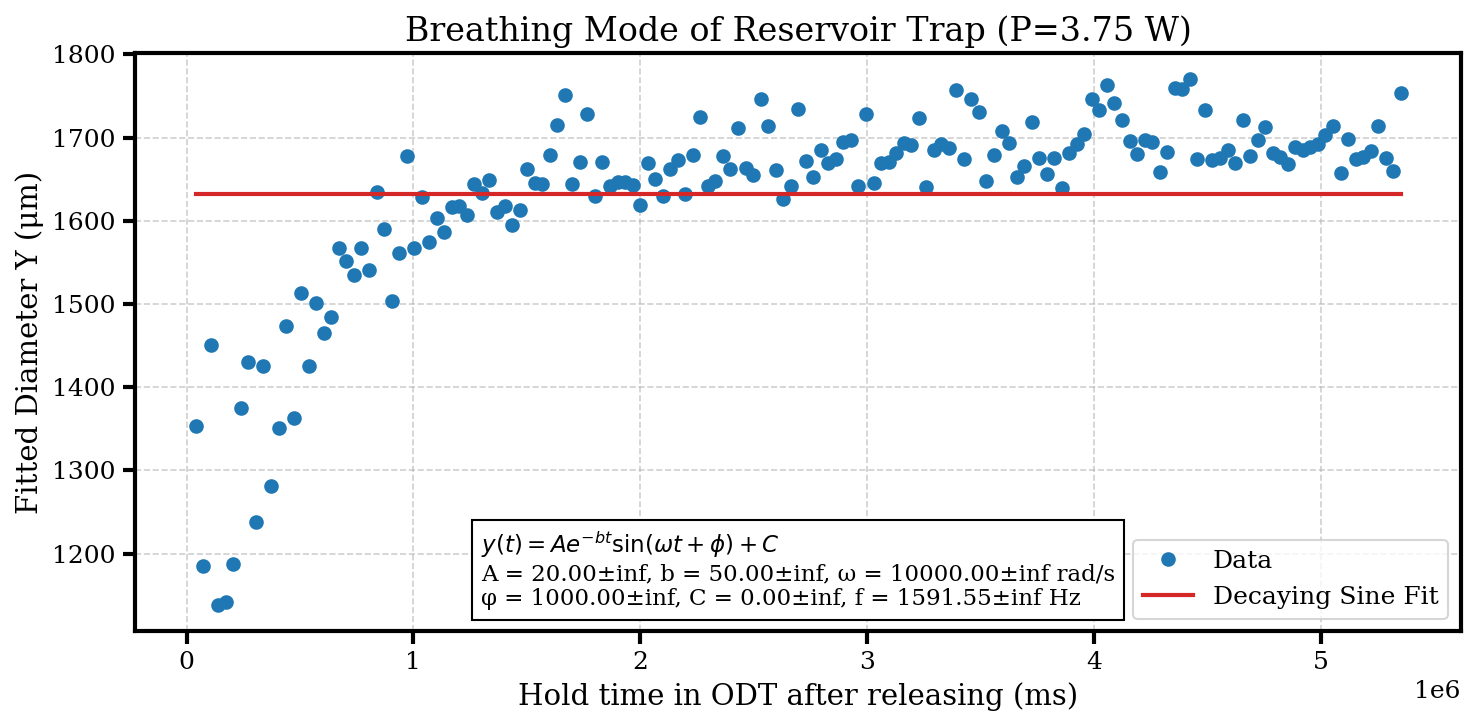

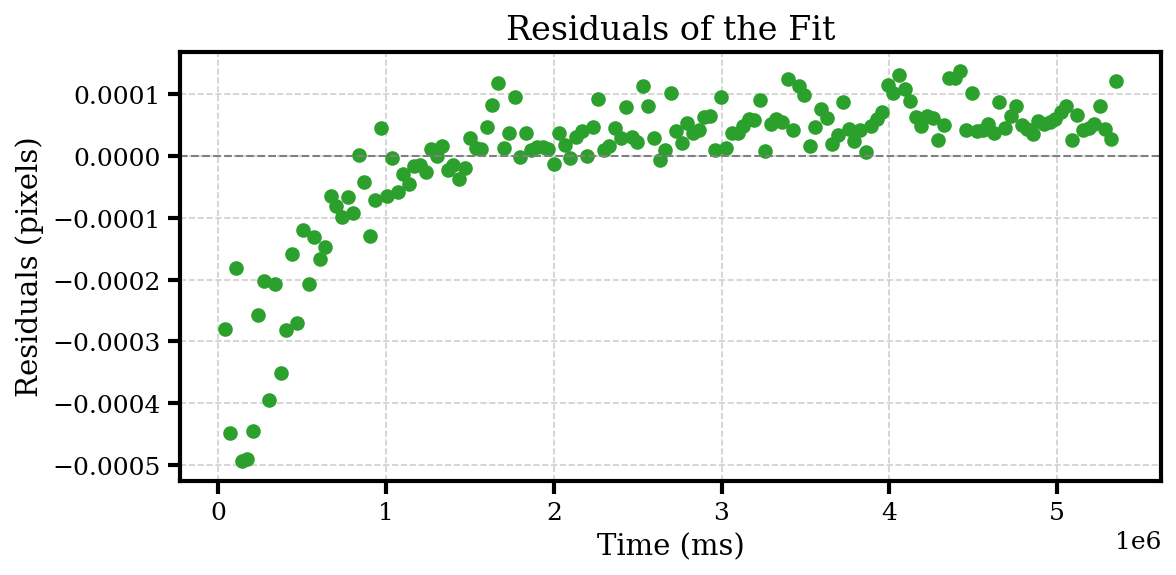

In [278]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# show the euation of the fit in latex
from matplotlib.offsetbox import AnchoredText

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl


fittype = "Diameter"
power_reservoir = 3.75

# if diameter then chnaged axis labels accordingly
if fittype == "Diameter":
    scale = 1e6
else:
    scale = 1.0


# Your data
t_data = np.array(scan_params)  # Time data
d_data = np.array(sx)  # Centroid data


print("Original Time data:", t_data)
print("Original Centroid data:", d_data)

# remove first point which is at t=0
# for i in range(len(t_data)):
#   if t_data[i]==0:
##       t_data = np.delete(t_data, i)
#    d_data = np.delete(d_data, i)
#     break

# Sort the data by time
sorted_indices = np.argsort(t_data)
t_data_sorted = t_data[sorted_indices]
d_data_sorted = d_data[sorted_indices]

# remove last 20 points from both t_data_sorted and d_data_sorted

# DIVIDE d_data_sorted by 10
t_data_sorted = t_data_sorted

# print the sorted data
print("Sorted Time data:", t_data_sorted)
print("Sorted Diameter data:", d_data_sorted)

# remove last 10 points from both t_data_sorted and d_data_sorted
# t_data_sorted = t_data_sorted[:-10]
# d_data_sorted = d_data_sorted[:-10]


# Define the decaying sine function
def decaying_sine(t, A, b, omega, phi, C):
    return A * np.exp(-b * t) * np.sin(omega * t + phi) + C


# === Simulated or real data ===
# Replace with your actual t_data_sorted and d_data_sorted
# t_data_sorted = np.array([...])
# d_data_sorted = np.array([...])
# scale = 1  # e.g., pixels to microns
# fittype = "Diameter"
# power_reservoir = 4.3

# === Initial guess ===
initial_guess = [20.0, 50.0, 10000.0, 1000, np.mean(d_data_sorted)]

# === Plot style ===
mpl.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.dpi": 150,
        "lines.linewidth": 2,
        "lines.markersize": 6,
        "text.usetex": False,
    }
)

# === Curve fitting ===
popt, pcov = curve_fit(decaying_sine, t_data_sorted, d_data_sorted, p0=initial_guess)
A_fit, b_fit, omega_fit, phi_fit, C_fit = popt
frequency = omega_fit / (2 * np.pi)
perr = np.sqrt(np.diag(pcov))
delta_frequency = perr[2] / (2 * np.pi)

# === Generate fit curve ===
t_fit = np.linspace(min(t_data_sorted), max(t_data_sorted), 1000)
d_fit = decaying_sine(t_fit, *popt)

# === Main plot ===
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", label="Data", color="tab:blue")
ax.plot(t_fit * 1e3, d_fit * scale, "-", label="Decaying Sine Fit", color="tab:red")

# === Labels and title ===
if fittype == "Diameter":
    ax.set_xlabel("Hold time in ODT after releasing (ms)")
    ax.set_ylabel("Fitted Diameter Y (μm)")
    ax.set_title(f"Breathing Mode of Reservoir Trap (P={power_reservoir} W)")
else:
    ax.set_xlabel("Hold time in ODT after releasing (ms)")
    ax.set_ylabel("Fitted Peak of Gaussian X (pixels)")
    ax.set_title(f"Reservoir Trap Frequency Measurement (P={power_reservoir} W)")

ax.legend(loc="lower right")
ax.grid(True, linestyle="--", alpha=0.6)

# === Annotated fit parameters ===
fit_eq = r"$y(t) = Ae^{-bt} \sin(\omega t + \phi) + C$"
fit_params = (
    f"A = {A_fit:.2f}±{perr[0]:.2f}, b = {b_fit:.2f}±{perr[1]:.2f}, "
    f"ω = {omega_fit:.2f}±{perr[2]:.2f} rad/s\n"
    f"φ = {phi_fit:.2f}±{perr[3]:.2f}, C = {C_fit:.2f}±{perr[4]:.2f}, "
    f"f = {frequency:.2f}±{delta_frequency:.2f} Hz"
)
at = AnchoredText(
    f"{fit_eq}\n{fit_params}", loc="lower center", frameon=True, prop=dict(size=11)
)
ax.add_artist(at)

# === Inset 1: Zoom on early oscillations ===
# axins1 = inset_axes(ax, width="30%", height="30%", loc="upper left", borderpad=2)
# axins1.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", color="tab:blue")
# axins1.plot(t_fit * 1e3, d_fit * scale, "-", color="tab:red")
# axins1.set_xlim(0, 1.5)
# axins1.set_ylim(min(d_fit*scale)*0.95, max(d_fit*scale)*1.05)
# axins1.set_xticks([])
# axins1.set_yticks([])
# axins1.set_title("Zoom: Initial Oscillations", fontsize=10)

# === Inset 2: Zoom on envelope decay ===
# axins2 = inset_axes(ax, width="30%", height="30%", loc="upper right", borderpad=2)
# axins2.plot(t_fit * 1e3, A_fit * np.exp(-b_fit * t_fit) * scale + C_fit * scale, "--", color="tab:gray", label="Envelope")
# axins2.plot(t_fit * 1e3, -A_fit * np.exp(-b_fit * t_fit) * scale + C_fit * scale, "--", color="tab:gray")
# axins2.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", color="tab:blue")
# axins2.plot(t_fit * 1e3, d_fit * scale, "-", color="tab:red")
# axins2.set_xlim(0, max(t_data_sorted) * 1e3)
# axins2.set_ylim(min(d_fit*scale)*0.95, max(d_fit*scale)*1.05)
# axins2.set_xticks([])
# axins2.set_yticks([])
# axins2.set_title("Zoom: Envelope Decay", fontsize=10)

plt.tight_layout()
plt.show()

# === Residuals plot ===
residuals = d_data_sorted - decaying_sine(t_data_sorted, *popt)
plt.figure(figsize=(8, 4))
plt.plot(t_data_sorted * 1e3, residuals, "o", color="tab:green")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Time (ms)")
plt.ylabel("Residuals (pixels)")
plt.title("Residuals of the Fit")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Original Time data: [  40.04289051   73.25261288  106.46954456  139.68736886  172.90209287
  206.1167114   239.31160147  272.49073755  305.74404064  338.95509974
  372.15846933  405.41307921  438.64399705  471.85368043  505.05615791
  538.478125    571.69672149  604.90807286  638.11984046  671.33541944
  704.55114254  737.76737838  770.98071209  804.20308496  837.41488207
  870.62334699  903.82915346  937.03956239  970.23658701 1003.44406554
 1036.64804179 1069.84452961 1103.04135393 1136.25201519 1169.43550241
 1202.63225301 1235.8243513  1269.02265109 1302.20835971 1335.39908631
 1368.59749407 1401.80273874 1435.00239223 1468.20812742 1501.40076433
 1534.60465963 1567.82465504 1601.02519276 1634.27786362 1667.47329404
 1700.67875945 1733.88036111 1767.06017358 1800.25396495 1833.4551089
 1866.66523124 1899.86405333 1933.07192443 1966.28246711 1999.47222577
 2032.66860092 2065.86455878 2099.05568232 2132.24506721 2165.4460277
 2198.64293557 2231.84701821 2265.04419371 2298.2476388  23

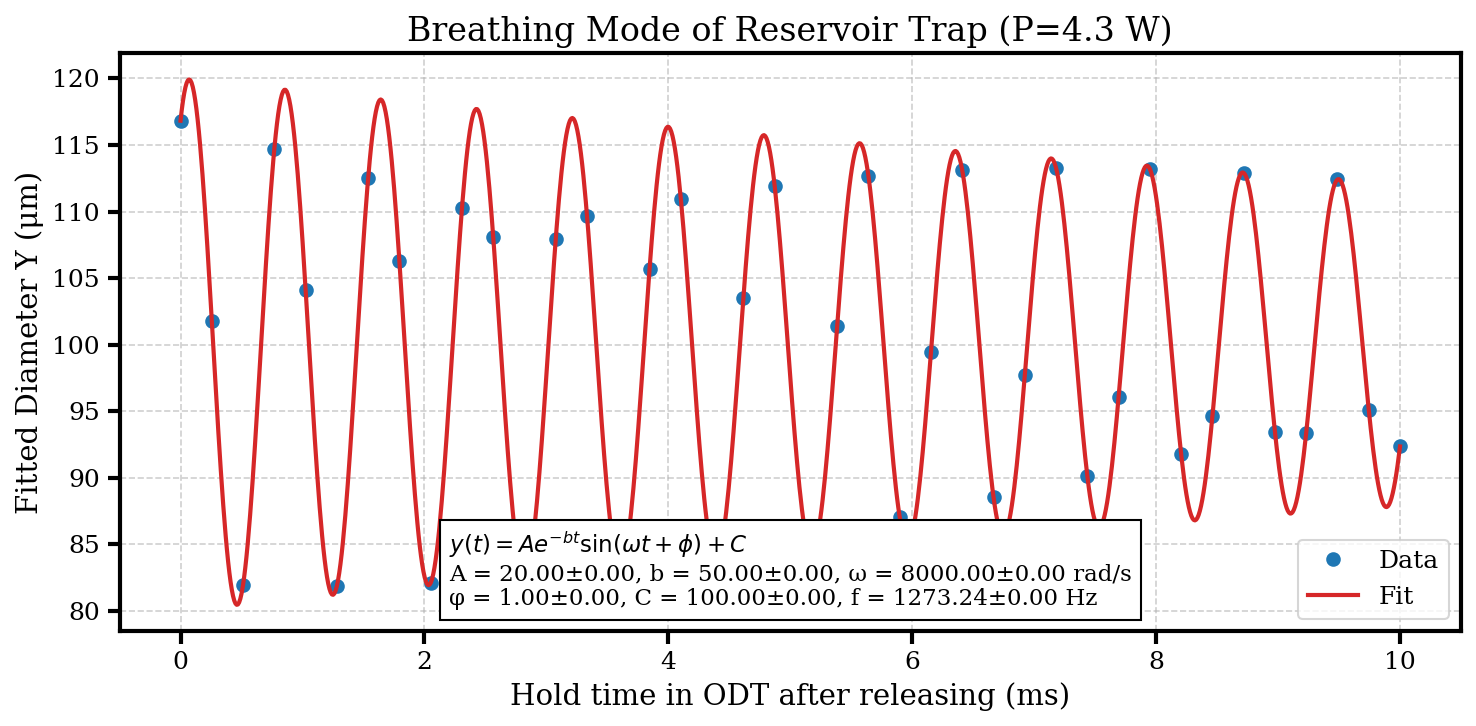

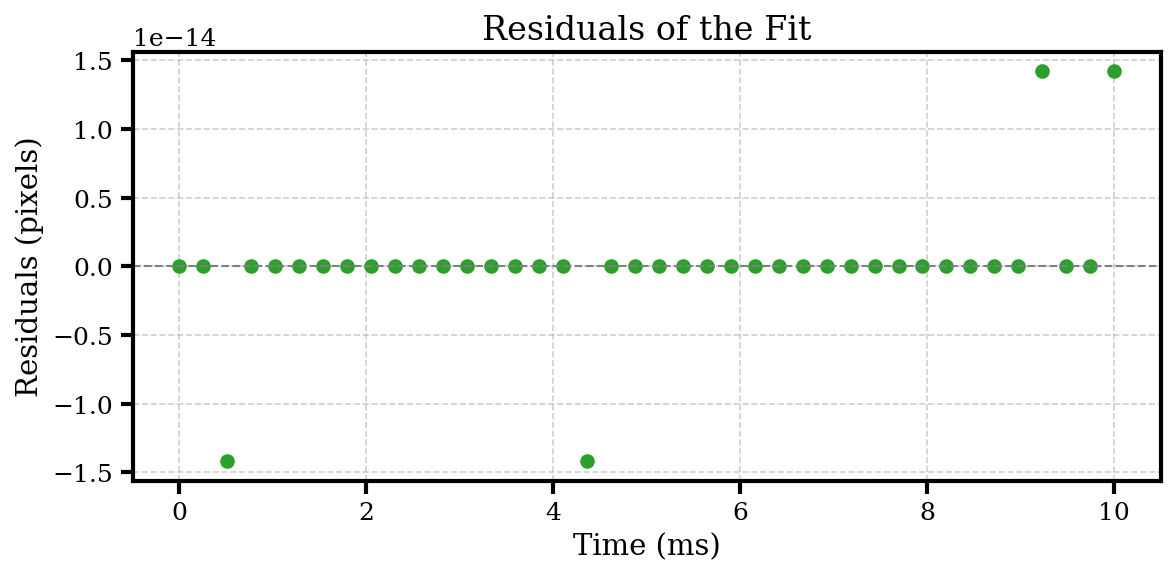

In [279]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# show the euation of the fit in latex
from matplotlib.offsetbox import AnchoredText


fittype = "Diameter"
power_reservoir = 3.75

# if diameter then chnaged axis labels accordingly
if fittype == "Diameter":
    scale = 1e6
else:
    scale = 1.0


# Your data
t_data = np.array(scan_params)  # Time data
d_data = np.array(sx)  # Centroid data


print("Original Time data:", t_data)
print("Original Centroid data:", d_data)

# remove first point which is at t=0
# for i in range(len(t_data)):
#   if t_data[i]==0:
##       t_data = np.delete(t_data, i)
#    d_data = np.delete(d_data, i)
#     break

# Sort the data by time
sorted_indices = np.argsort(t_data)
t_data_sorted = t_data[sorted_indices]
d_data_sorted = d_data[sorted_indices]

# remove last 20 points from both t_data_sorted and d_data_sorted

# DIVIDE d_data_sorted by 10
t_data_sorted = t_data_sorted

# print the sorted data
print("Sorted Time data:", t_data_sorted)
print("Sorted Diameter data:", d_data_sorted)

# remove last 10 points from both t_data_sorted and d_data_sorted
# t_data_sorted = t_data_sorted[:-10]
# d_data_sorted = d_data_sorted[:-10]


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, AnchoredText
import matplotlib as mpl
from PIL import Image
import io

# -------------------------------
# Simulated Data Setup (for demo)
# -------------------------------
# Replace this section with your actual data
t_data_sorted = np.linspace(0, 0.01, 40)  # seconds
true_params = [20.0, 50.0, 8000.0, 1.0, 100.0]
d_data_sorted = (
    true_params[0]
    * np.exp(-true_params[1] * t_data_sorted)
    * np.sin(true_params[2] * t_data_sorted + true_params[3])
    + true_params[4]
)
scale = 1  # No scaling
fittype = "Diameter"
power_reservoir = 4.3

# Toggleable options
show_fit_params = True
show_residuals = True
show_insets = False
show_extra_images = False


# Dummy images (you can load real ones)
def create_sample_image(color):
    img = Image.new("RGB", (60, 60), color=color)
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    return plt.imread(buf)


img1 = create_sample_image("red")
img2 = create_sample_image("blue")


# Fit function
def decaying_sine(t, A, b, omega, phi, C):
    return A * np.exp(-b * t) * np.sin(omega * t + phi) + C


# Fit
initial_guess = [20.0, 50.0, 8000.0, 1.0, np.mean(d_data_sorted)]
popt, pcov = curve_fit(decaying_sine, t_data_sorted, d_data_sorted, p0=initial_guess)
A_fit, b_fit, omega_fit, phi_fit, C_fit = popt
frequency = omega_fit / (2 * np.pi)
perr = np.sqrt(np.diag(pcov))
delta_frequency = perr[2] / (2 * np.pi)
t_fit = np.linspace(min(t_data_sorted), max(t_data_sorted), 1000)
d_fit = decaying_sine(t_fit, *popt)

# Plot style
mpl.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "figure.dpi": 150,
    }
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", label="Data", color="tab:blue")
ax.plot(t_fit * 1e3, d_fit * scale, "-", label="Fit", color="tab:red")

if fittype == "Diameter":
    ax.set_xlabel("Hold time in ODT after releasing (ms)")
    ax.set_ylabel("Fitted Diameter Y (μm)")
    ax.set_title(f"Breathing Mode of Reservoir Trap (P={power_reservoir} W)")

ax.legend(loc="lower right")
ax.grid(True, linestyle="--", alpha=0.6)

# Fit info box
if show_fit_params:
    fit_eq = r"$y(t) = Ae^{-bt} \sin(\omega t + \phi) + C$"
    fit_params = (
        f"A = {A_fit:.2f}±{perr[0]:.2f}, b = {b_fit:.2f}±{perr[1]:.2f}, "
        f"ω = {omega_fit:.2f}±{perr[2]:.2f} rad/s\n"
        f"φ = {phi_fit:.2f}±{perr[3]:.2f}, C = {C_fit:.2f}±{perr[4]:.2f}, "
        f"f = {frequency:.2f}±{delta_frequency:.2f} Hz"
    )
    at = AnchoredText(
        f"{fit_eq}\n{fit_params}", loc="lower center", frameon=True, prop=dict(size=11)
    )
    ax.add_artist(at)

# Optional inset showing envelope
if show_insets:
    axins = inset_axes(ax, width="30%", height="30%", loc="upper right")
    axins.plot(
        t_fit * 1e3,
        A_fit * np.exp(-b_fit * t_fit) * scale + C_fit * scale,
        "--",
        color="gray",
    )
    axins.plot(
        t_fit * 1e3,
        -A_fit * np.exp(-b_fit * t_fit) * scale + C_fit * scale,
        "--",
        color="gray",
    )
    axins.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", color="tab:blue")
    axins.plot(t_fit * 1e3, d_fit * scale, "-", color="tab:red")
    axins.set_title("Envelope", fontsize=10)
    axins.set_xticks([])
    axins.set_yticks([])

# Add extra images at two data points
if show_extra_images:
    idx1, idx2 = 5, 25
    time1, time2 = t_data_sorted[idx1] * 1e3, t_data_sorted[idx2] * 1e3
    pos1 = (time1, d_data_sorted[idx1] * scale)
    pos2 = (time2, d_data_sorted[idx2] * scale)

    imagebox1 = OffsetImage(img1, zoom=0.6)
    ab1 = AnnotationBbox(imagebox1, pos1, xycoords="data", frameon=True)
    ax.add_artist(ab1)

    imagebox2 = OffsetImage(img2, zoom=0.6)
    ab2 = AnnotationBbox(imagebox2, pos2, xycoords="data", frameon=True)
    ax.add_artist(ab2)

plt.tight_layout()
plt.show()

# Residuals plot
if show_residuals:
    residuals = d_data_sorted - decaying_sine(t_data_sorted, *popt)
    plt.figure(figsize=(8, 4))
    plt.plot(t_data_sorted * 1e3, residuals, "o", color="tab:green")
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("Time (ms)")
    plt.ylabel("Residuals (pixels)")
    plt.title("Residuals of the Fit")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

x0 positions: [300.27280805755265, 301.5983589476001, 300.4560187828307, 303.0601964587085, 299.2291213843797, 303.1774162179335, 302.2780971749016, 301.56140027889006, 303.7411774924299, 302.0315463747219, 303.2662312845963, 302.79158455240054, 304.0899446420325, 304.57347100499317, 306.0597767477048, 303.20784351652856, 302.69450297475987, 304.03839025075723, 304.1872891202402, 306.09892744423775, 303.62402271018595, 300.93111351707006, 303.11630078932296, 304.9181460256904, 305.1473967309375, 304.29092465924657, 303.6151828546905, 305.3646934885693, 302.6614508068457, 303.5668542800997, 304.98762507609183, 305.0849481337394, 304.2680070222133, 303.66044269915966, 304.32299028164266, 303.86372227912136, 305.7245740537796, 303.79264520346715, 303.15316885882487, 301.44973987755895, 304.531275595824, 304.41622145031056, 304.2987490167783, 302.9805358492345, 301.3232232281842, 304.5432235540743, 306.7183718561058, 305.08724943941905, 301.29798015789515, 301.81012222031256, 303.754794183

/home/ae19663/anaconda3/envs/artiq/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ae19663/anaconda3/envs/artiq/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


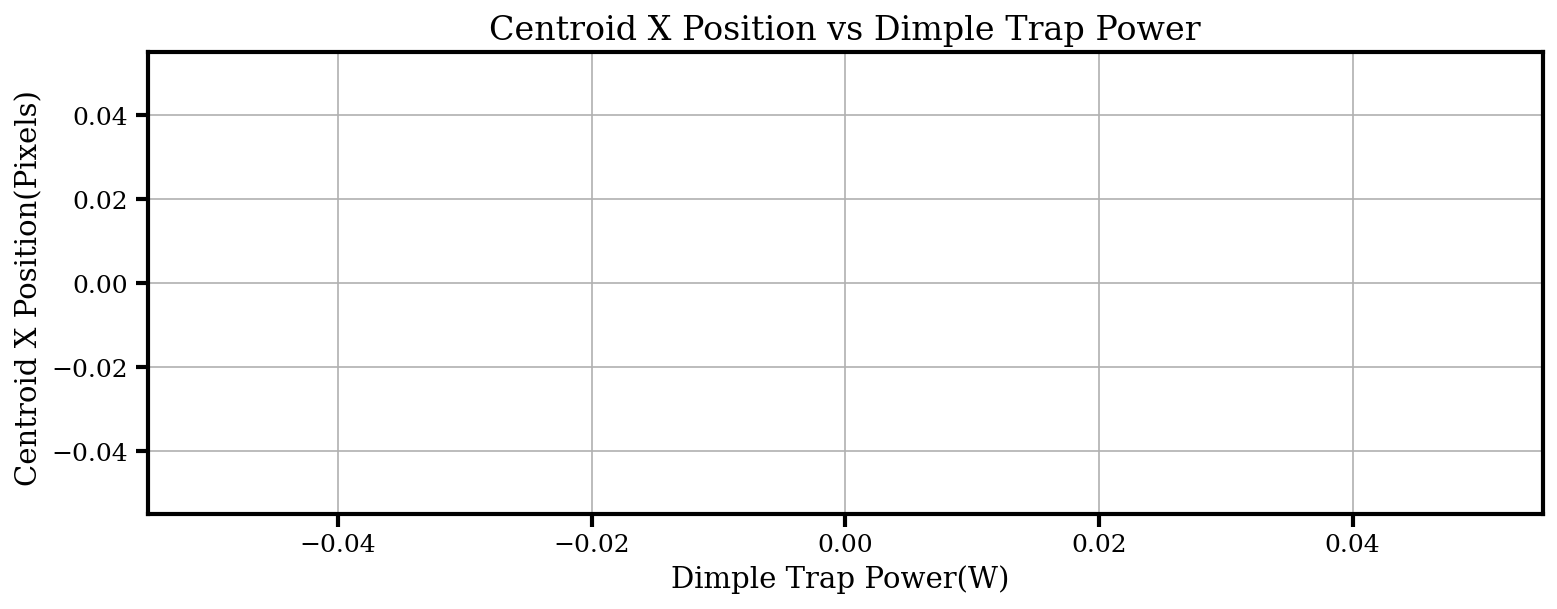

<Figure size 960x720 with 0 Axes>

In [280]:
# plotting the voltage vs the x0 and y0 positions
# print arrays x0 and the scan_params
print("x0 positions:", x0)
print("Scan parameters (MOT Coil Current):", scan_params)
print("y0 positions:", y0)

# scan param is the index of the x0 and y0 arrays

# short the elemnts of the arrays based on scan_params
# sort scan_params and get the indices
sorted_indices = np.argsort(scan_params)
scan_params_sorted = np.array(scan_params)[sorted_indices]
x0_sorted = np.array(centroidx)[sorted_indices]
y0_sorted = np.array(centroidy)[sorted_indices]

# range of scan parameter is from 0.5 to 1.5 and chnage x0 and y0 accordingly
# filter the arrays based on scan_params_sorted
filter_mask = (scan_params_sorted >= 0.6) & (scan_params_sorted <= 1.3)
scan_params_sorted = scan_params_sorted[filter_mask]
x0_sorted = x0_sorted[filter_mask]
y0_sorted = y0_sorted[filter_mask]

# mean center the x0 and y0 positions
x0_sorted = x0_sorted - np.mean(x0_sorted)
y0_sorted = y0_sorted - np.mean(y0_sorted)

slope = 4251.730690
Intercept = -38.470849


# using above eqationchnage volage into power
def voltage_to_power(voltage):
    return slope * voltage + Intercept


scan_params_sorted = voltage_to_power(scan_params_sorted)

plot_general(
    scan_params_sorted * 1e-3,
    x0_sorted,
    "Dimple Trap Power(W)",
    "Centroid X Position(Pixels)",
    "Centroid X Position vs Dimple Trap Power",
    color="r",
)

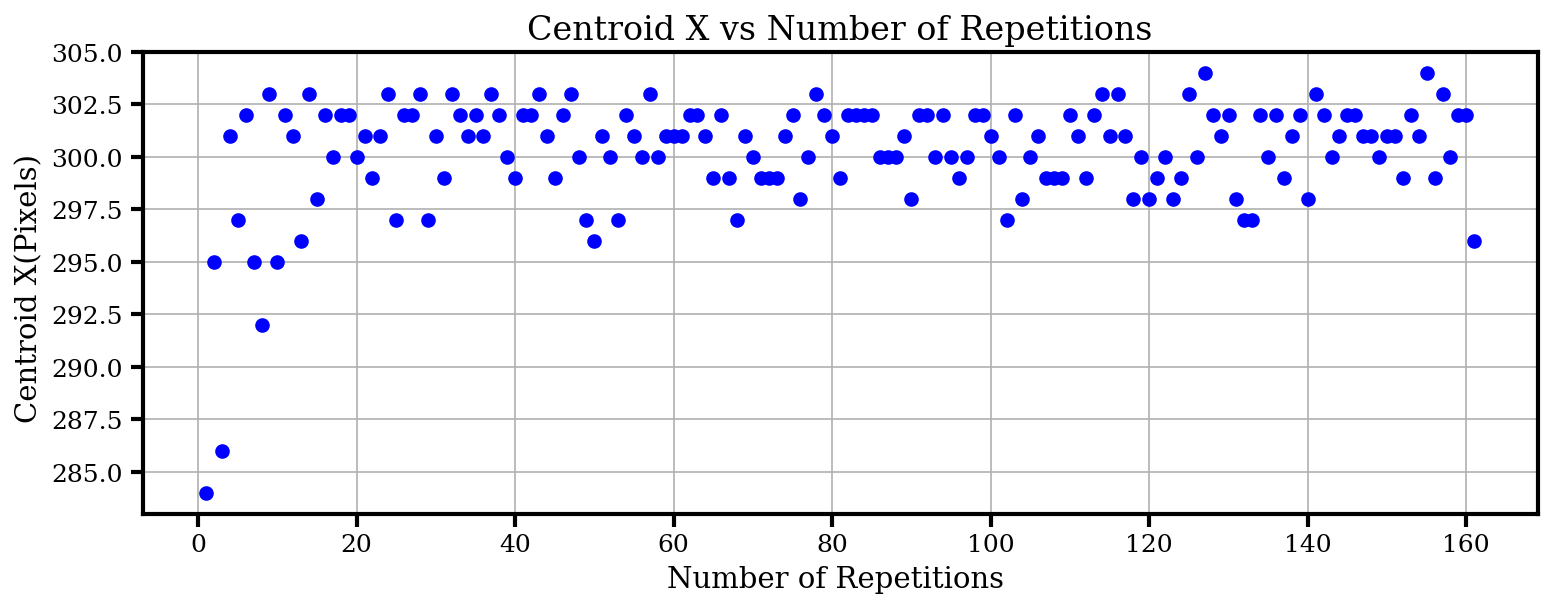

<Figure size 960x720 with 0 Axes>

In [281]:
# plot x0 vs the its array index
# make a array of idices from 1 to len(x0)
x0_indices = np.arange(1, len(x0) + 1)

# plot x0 vs the its array index
plot_general(
    x0_indices,
    centroidx,
    "Number of Repetitions",
    "Centroid X(Pixels)",
    "Centroid X vs Number of Repetitions",
    color="b",
)

In [282]:
import numpy as np
import matplotlib.pyplot as plt


class EllipticalGaussianBeam:
    """
    Elliptical Gaussian beam.

    Parameters
    ----------
    wavelength : float
        Laser wavelength (meters)
    wx0 : float
        Beam waist in x at z=0 (meters)
    wy0 : float
        Beam waist in y at z=0 (meters)
    amplitude : float
        Electric field amplitude
    theta : float
        Rotation angle (radians)
    """

    def __init__(self, wavelength, wx0, wy0, amplitude=1.0, theta=0.0):

        self.lambda0 = wavelength
        self.wx0 = wx0
        self.wy0 = wy0
        self.amplitude = amplitude
        self.theta = theta

        # Wave number
        self.k = 2 * np.pi / wavelength

        # Rayleigh ranges
        self.zRx = np.pi * wx0**2 / wavelength
        self.zRy = np.pi * wy0**2 / wavelength

    # ---------------------------------------------------------

    def beam_radius(self, z):
        """Beam radii at propagation distance z."""
        wx = self.wx0 * np.sqrt(1 + (z / self.zRx) ** 2)
        wy = self.wy0 * np.sqrt(1 + (z / self.zRy) ** 2)
        return wx, wy

    # ---------------------------------------------------------

    def radius_of_curvature(self, z):
        """Radius of curvature."""
        Rx = np.inf if z == 0 else z * (1 + (self.zRx / z) ** 2)
        Ry = np.inf if z == 0 else z * (1 + (self.zRy / z) ** 2)
        return Rx, Ry

    # ---------------------------------------------------------

    def gouy_phase(self, z):
        """Gouy phase."""
        return np.arctan(z / self.zRx), np.arctan(z / self.zRy)

    # ---------------------------------------------------------

    def rotate(self, X, Y):
        """Rotate coordinates."""
        if self.theta == 0:
            return X, Y

        ct = np.cos(self.theta)
        st = np.sin(self.theta)

        Xr = X * ct + Y * st
        Yr = -X * st + Y * ct

        return Xr, Yr

    # ---------------------------------------------------------

    def field(self, X, Y, z=0):
        """
        Complex electric field.
        """

        wx, wy = self.beam_radius(z)
        Rx, Ry = self.radius_of_curvature(z)
        gx, gy = self.gouy_phase(z)

        Xr, Yr = self.rotate(X, Y)

        amplitude = (
            self.amplitude
            * np.sqrt(self.wx0 * self.wy0 / (wx * wy))
            * np.exp(-(Xr**2 / wx**2 + Yr**2 / wy**2))
        )

        phase = np.exp(
            -1j
            * (
                self.k * z
                + self.k * Xr**2 / (2 * Rx)
                + self.k * Yr**2 / (2 * Ry)
                - 0.5 * (gx + gy)
            )
        )

        return amplitude * phase

    # ---------------------------------------------------------

    def intensity(self, X, Y, z=0):
        """Beam intensity."""
        E = self.field(X, Y, z)
        return np.abs(E) ** 2

    # ---------------------------------------------------------

    def grid(self, xmin, xmax, ymin, ymax, points=400):
        """
        Create mesh grid.
        """
        x = np.linspace(xmin, xmax, points)
        y = np.linspace(ymin, ymax, points)

        return np.meshgrid(x, y)

    # ---------------------------------------------------------

    def plot_intensity(self, xmin, xmax, ymin, ymax, z=0, points=400, cmap="inferno"):

        X, Y = self.grid(xmin, xmax, ymin, ymax, points)

        I = self.intensity(X, Y, z)

        plt.figure(figsize=(6, 5))
        plt.imshow(
            I,
            extent=[xmin, xmax, ymin, ymax],
            origin="lower",
            cmap=cmap,
        )
        plt.xlabel("x (m)")
        plt.ylabel("y (m)")
        plt.title(f"Elliptical Gaussian Beam (z={z:.3g} m)")
        plt.axis("equal")
        plt.colorbar(label="Intensity")
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------

    def plot_surface(self, xmin, xmax, ymin, ymax, z=0, points=200):

        from mpl_toolkits.mplot3d import Axes3D

        X, Y = self.grid(xmin, xmax, ymin, ymax, points)
        I = self.intensity(X, Y, z)

        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection="3d")

        ax.plot_surface(
            X,
            Y,
            I,
            cmap="viridis",
            linewidth=0,
            antialiased=True,
        )

        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.set_zlabel("Intensity")

        plt.tight_layout()
        plt.show()


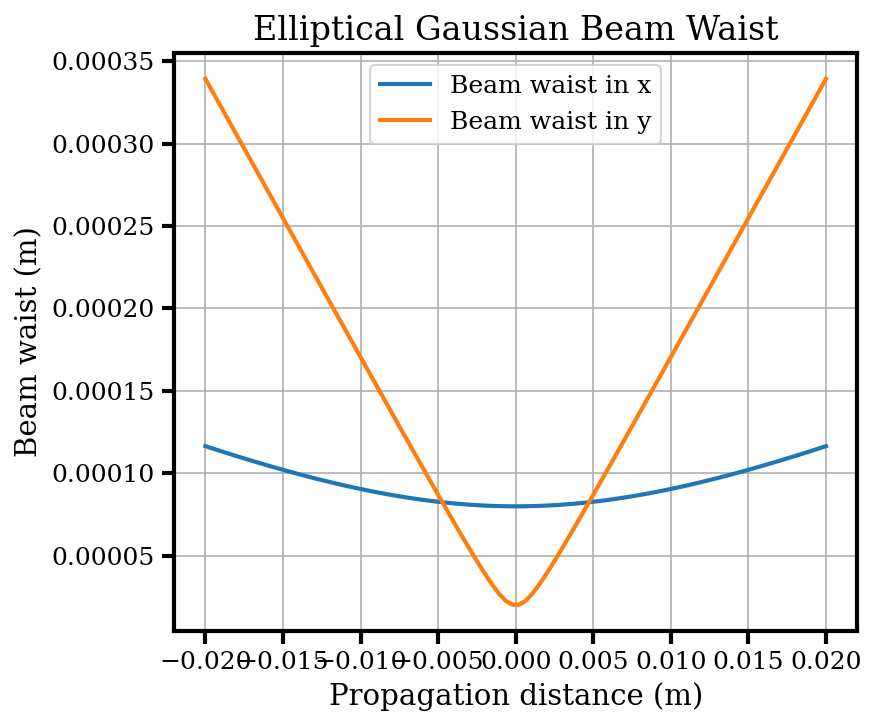

Beam waist at z=0.01 m: wx=0.09 mm, wy=0.17 mm


In [283]:
beam=EllipticalGaussianBeam(wavelength=1064e-9, wx0=80e-6, wy0=20e-6, amplitude=1.0, theta=np.pi/6)
# linear plot waist as function of +z to -z
z_vals = np.linspace(-0.02, 0.02, 100)
wx_vals, wy_vals = beam.beam_radius(z_vals)
plt.figure(figsize=(6, 5))
plt.plot(z_vals, wx_vals, label="Beam waist in x")
plt.plot(z_vals, wy_vals, label="Beam waist in y")
plt.xlabel("Propagation distance (m)")
plt.ylabel("Beam waist (m)")
plt.title("Elliptical Gaussian Beam Waist")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# give waist at arbitray z position
z_position = 0.01  # meters
wx_at_z, wy_at_z = beam.beam_radius(z_position)
print(f"Beam waist at z={z_position} m: wx={wx_at_z*1e3:.2f} mm, wy={wy_at_z*1e3:.2f} mm")

